## Import

In [2]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neural_network import MLPRegressor

In [3]:
from ML.utils.utils import *
from ML.utils.Data_preparator import Data_preparator
from ML.utils.Model_evaluator import Model_evaluator
from physics.Iso_data_handler import Iso_data_handler
from physics.Data_visualiser import Data_visualiser

In [4]:
pre_path = "../../../../../../../"
physical_model = "MIST"
path_to_data = pre_path + "data/MIST_v1.2_vvcrit0.0_basic_isos/"
path_to_results = pre_path + "results/model_A_partial/default_models/"
path_to_predictions = pre_path + "predictions/model_A_partial/default_models/"
tag = "scale_robust_14"
output_parameters = ['mass', 'radius']
categories_name = ["phase"]

In [5]:
override = True
use_preds = False
save = True
show = True
scaler_name = "robust"

## Data preparation

This notebook contains the results of the model which are trained using all the data from MIST and filtered on the phases

Reading MIST dataframe from MIST_reclassified_iso_full_data.csv file...


,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.0,3.486221,3.131342,-1.0,-0.25,0.100000,0.153402
1,5.0,3.487362,3.126808,-1.0,-0.25,0.102645,0.160326
2,5.0,3.489243,3.119367,-1.0,-0.25,0.107039,0.171785
3,5.0,3.491102,3.112165,-1.0,-0.25,0.111419,0.183099
4,5.0,3.492937,3.105143,-1.0,-0.25,0.115789,0.194305
...,...,...,...,...,...,...,...
1467117,10.3,4.402490,7.777159,6.0,0.50,0.532726,-1.806255
1467118,10.3,4.387132,7.783242,6.0,0.50,0.532730,-1.809295
1467119,10.3,4.371789,7.789130,6.0,0.50,0.532735,-1.812237
1467120,10.3,4.356480,7.794844,6.0,0.50,0.532741,-1.815091


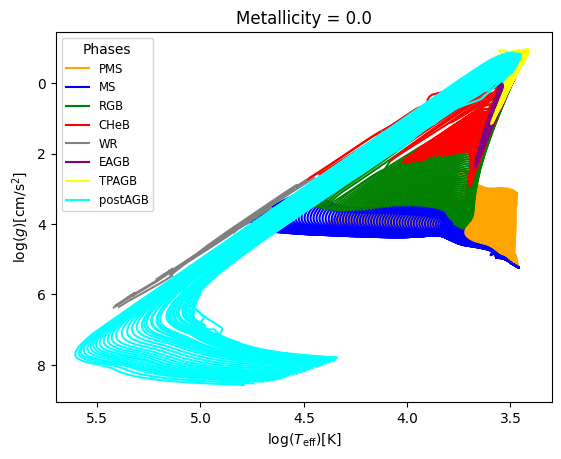

In [6]:
iso_handler = Iso_data_handler(path_to_data, 
                              ['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'phase', 'metallicity', 'star_mass', 'log_R'], 
                              physical_model, reclassify=True)

iso_df = iso_handler.get_isochrone_dataframe()
display(iso_df)
data_visualiser = Data_visualiser(iso_df, physical_model)
data_visualiser.plot_Kiel([], [0.0])

,log10_isochrone_age_yr,log_Teff,log_g,phase,metallicity,star_mass,log_R
0,5.00,4.494412,4.346972,0.0,-0.25,13.584360,0.610679
1,5.00,4.497517,4.345776,0.0,-0.25,13.765512,0.614753
2,5.00,4.500556,4.344580,0.0,-0.25,13.942887,0.618755
3,5.05,4.482577,4.350883,0.0,-0.25,12.925175,0.596074
4,5.05,4.485667,4.349692,0.0,-0.25,13.105490,0.600130
...,...,...,...,...,...,...,...
519286,10.30,3.602322,1.827453,3.0,0.50,0.866616,1.274247
519287,10.30,3.600999,1.809405,3.0,0.50,0.866614,1.283270
519288,10.30,3.599710,1.791489,3.0,0.50,0.866612,1.292228
519289,10.30,3.598418,1.773621,3.0,0.50,0.866610,1.301161


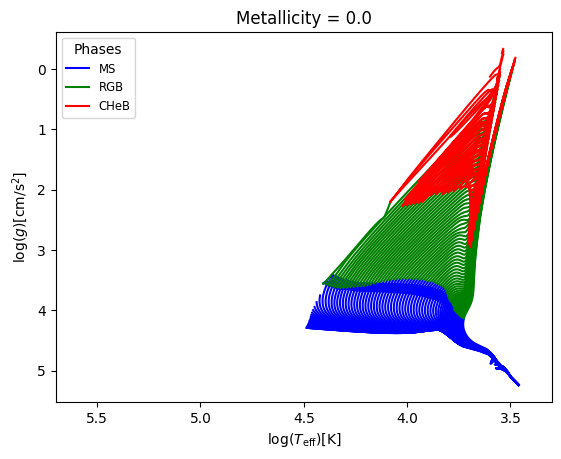

In [7]:
phase_filtered_iso_df = Data_preparator.filter_data(iso_df, {'phase':[0, 2, 3], 'star_mass':('<', 14)})
display(phase_filtered_iso_df)
data_visualiser_phase_filtered = Data_visualiser(phase_filtered_iso_df, physical_model)
data_visualiser_phase_filtered.plot_Kiel([], [0.0])

In [8]:
print_all_uniques(phase_filtered_iso_df)

log10_isochrone_age_yr  : Range : 5.0 - 10.3, Mean : 8.4629, Median : 8.5

log_Teff  : Range : 3.34 - 4.6345, Mean : 3.9346, Median : 3.8644

log_g  : Range : -1.08 - 5.4331, Mean : 3.5485, Median : 3.9492

Values in phase column : 0.0, 2.0, 3.0 

Values in metallicity column : -0.25, -0.5, -0.75, -1.0, -1.25, -1.5, -1.75, -2.0, -2.5, -3.0, -3.5, -4.0, 0.0, 0.25, 0.5 

star_mass  : Range : 0.1 - 13.9995, Mean : 3.398, Median : 2.0471

log_R  : Range : -1.0 - 3.0828, Mean : 0.6067, Median : 0.5386



In [9]:
X_train, X_ivs, y_train, y_ivs, categories_train, categories_ivs = \
    Data_preparator.split_data(phase_filtered_iso_df, x_cols=['log10_isochrone_age_yr', 'log_Teff', 'log_g', 'metallicity'], 
                               y_cols=['star_mass', 'log_R'], categories_cols=['phase'], random_state=12, print_stats=True)

print(X_train.shape, X_ivs.shape)
print(y_train.shape, y_ivs.shape)

Training set statistics:
Range in train data for the star_mass parameter : 0.0999979840073621 - 13.998624815474695
Median value in train data for the star_mass parameter: 2.0464342686349397
Mean value in train data for the star_mass parameter: 3.3973846370701644

Range in train data for the log_R parameter : -0.9974747647513328 - 3.082068881511837
Median value in train data for the log_R parameter: 0.5381900688843242
Mean value in train data for the log_R parameter: 0.6069651248403705

Testing set statistics:
Range in test data for the star_mass parameter : 0.0999981896729906 - 13.99946885003588
Median value in test data for the star_mass parameter: 2.048860774010381
Mean value in test data for the star_mass parameter: 3.399812923045874

Range in test data for the log_R parameter : -0.9974234436680278 - 3.0827540579576227
Median value in test data for the log_R parameter: 0.5398730026691951
Mean value in test data for the log_R parameter: 0.6057854356870224

(389468, 4) (129823, 4)
(38

## Model training

### Linear regression

In [10]:
lr_evaluator = Model_evaluator("linear_regression", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.7035807035771293
  RMSE :  1.7944310575952576
  MAE :  1.4533067736505216
  MedAE :  1.239029276414911
  CORR :  0.8532020075802776
  MAX_ER :  7.719467844929202
  Percentiles : 
    75th percentile :  2.059064024993024
    90th percentile :  2.8255989755778
    95th percentile :  3.3158861311329266
    99th percentile :  4.9831182334968664

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.7627584839179442
  RMSE :  1.5838867857754884
  MAE :  1.0715385149714316
  MedAE :  0.7504074523788256
  CORR :  0.9184081581407213
  MAX_ER :  7.092367586463915
  Percentiles : 
    75th percentile :  1.1937892073383636
    90th percentile :  2.321949633802711
    95th percentile :  4.01996020997168

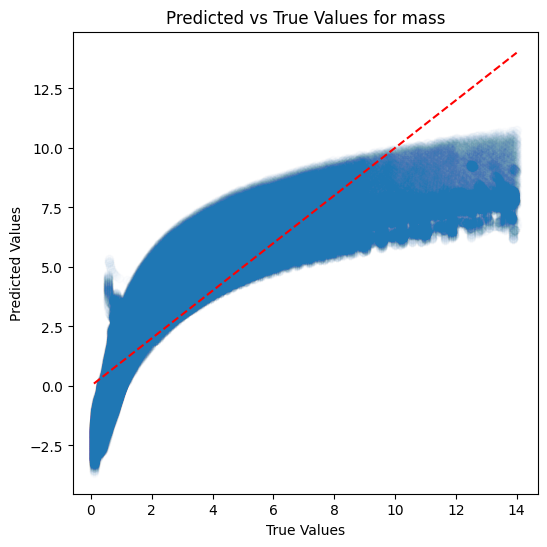

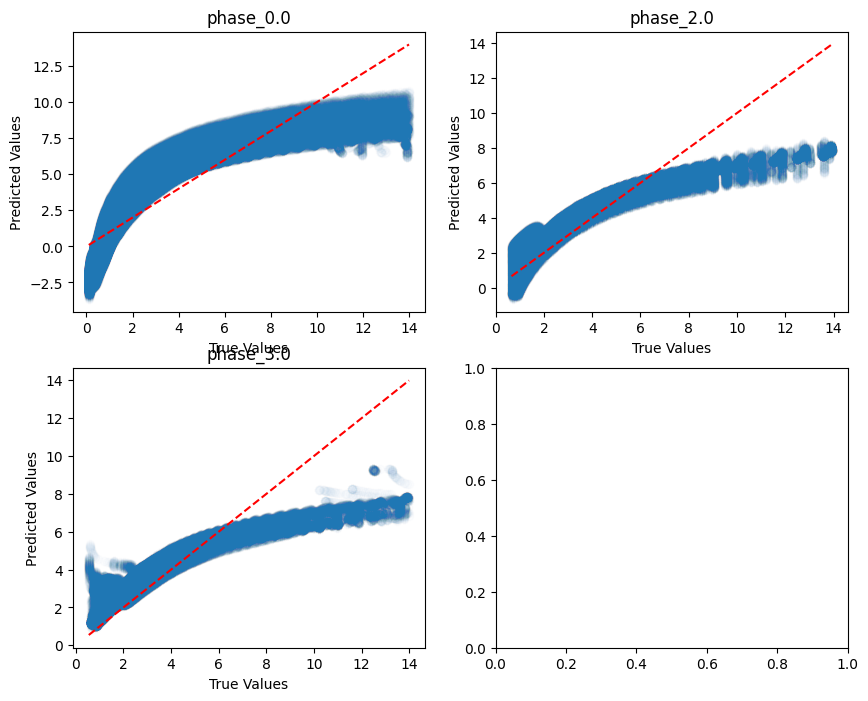

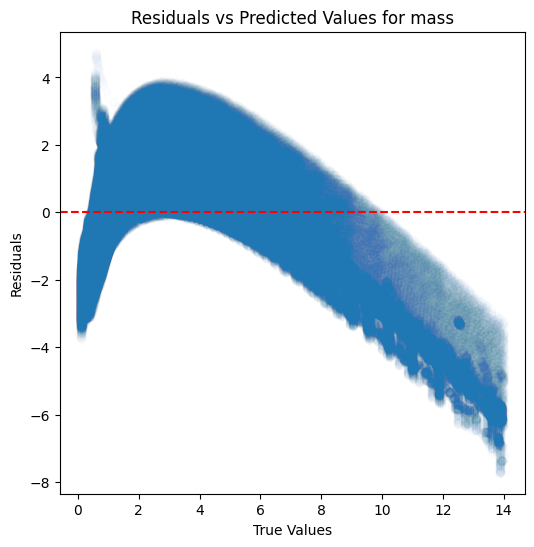

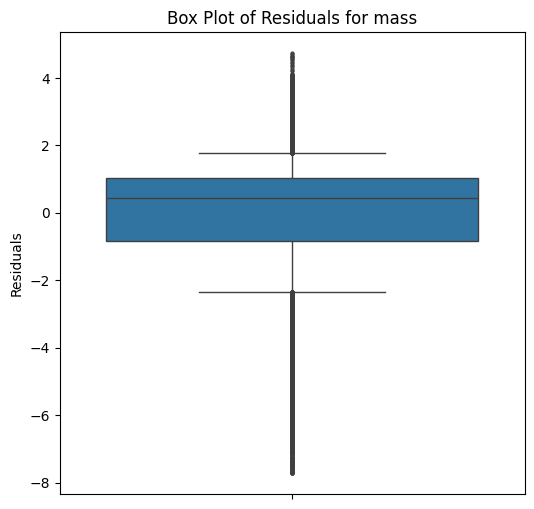

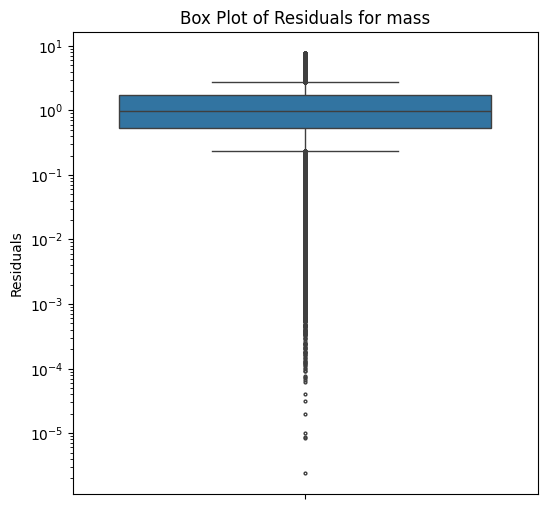

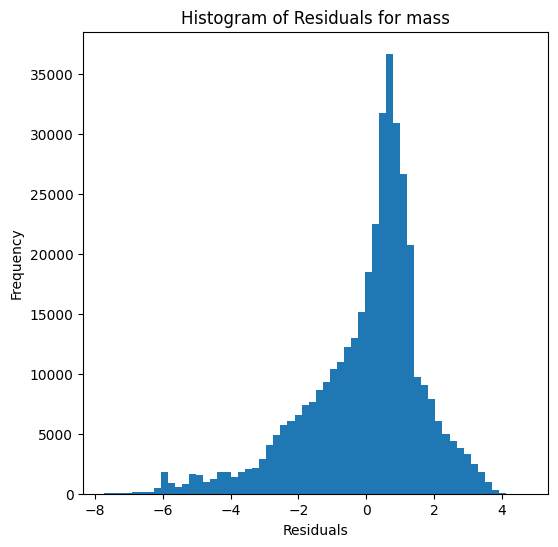

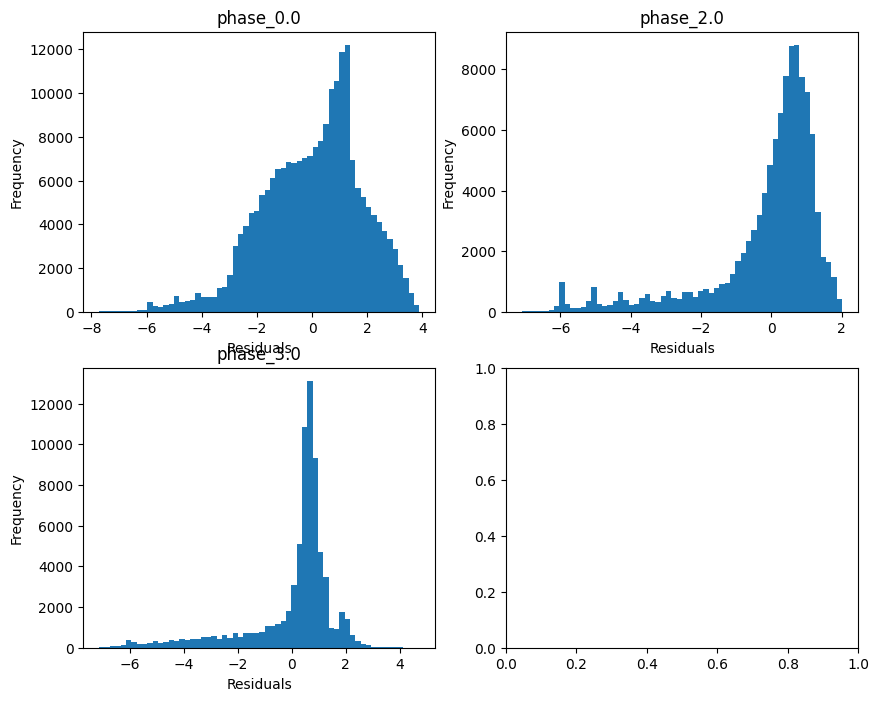

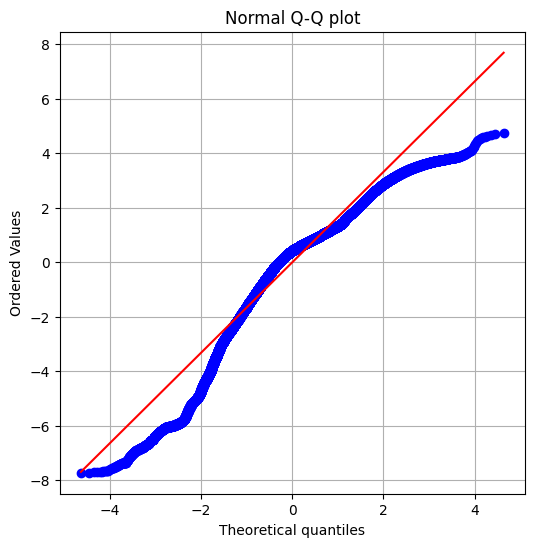

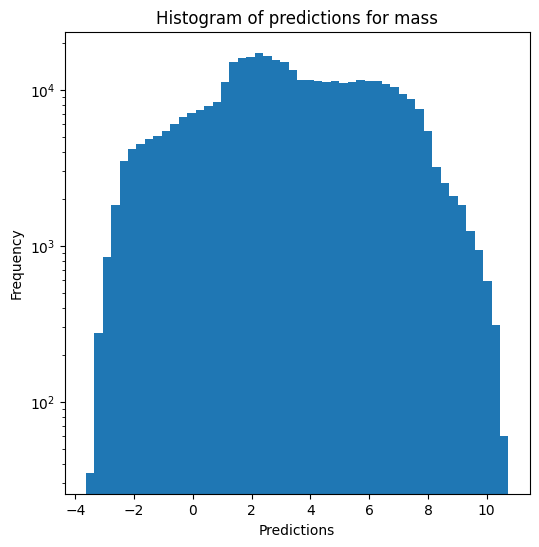

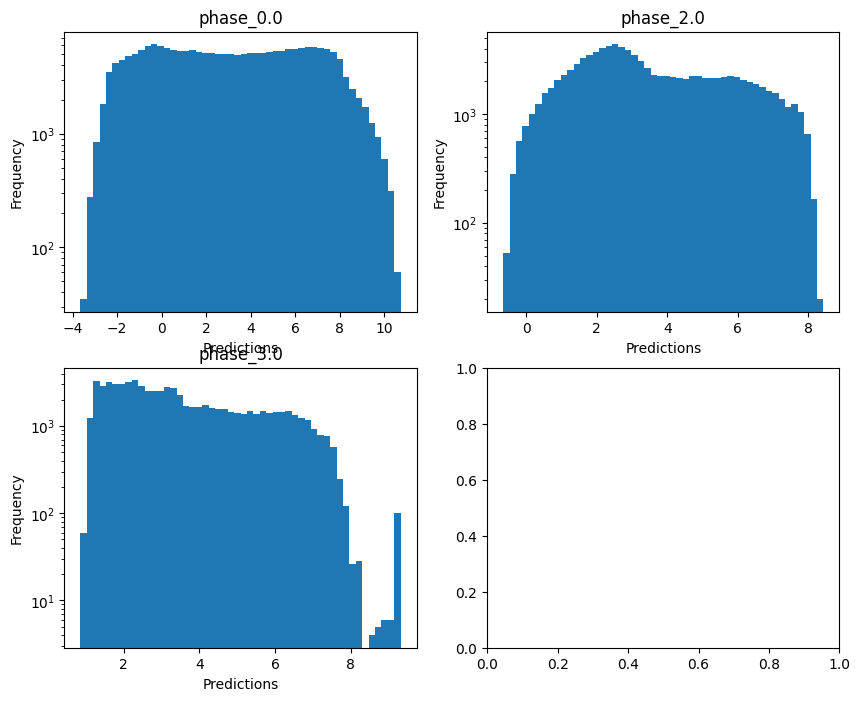

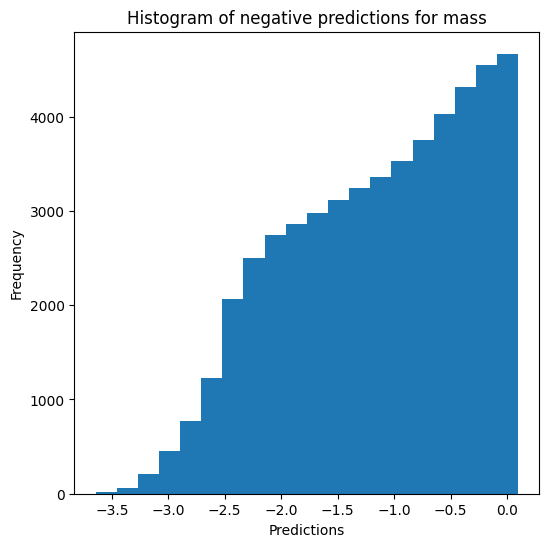


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.983049632308785
  RMSE :  0.05520328535718962
  MAE :  0.04232385004843037
  MedAE :  0.03380761139016103
  CORR :  0.991488594171592
  MAX_ER :  0.21950730766514603
  Percentiles : 
    75th percentile :  0.0635831491086693
    90th percentile :  0.0918315116595647
    95th percentile :  0.10867394268201569
    99th percentile :  0.15558805272503207

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9806856109752664
  RMSE :  0.06618133063179542
  MAE :  0.05156292525842142
  MedAE :  0.04193665494449467
  CORR :  0.9909797904600516
  MAX_ER :  0.24910103749840218
  Percentiles : 
    75th percentile :  0.07266590465907852
    90th percentile :  0.10861353273073998
    95th percentile :  0.1344997049312425
    99th percentile :  0.18544938117126641

radius results for the phase categor

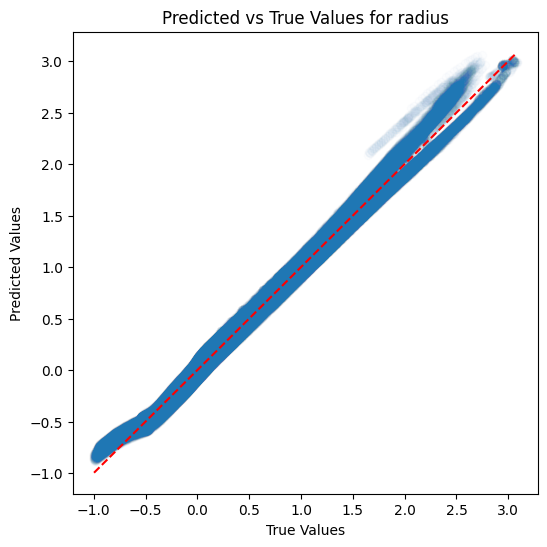

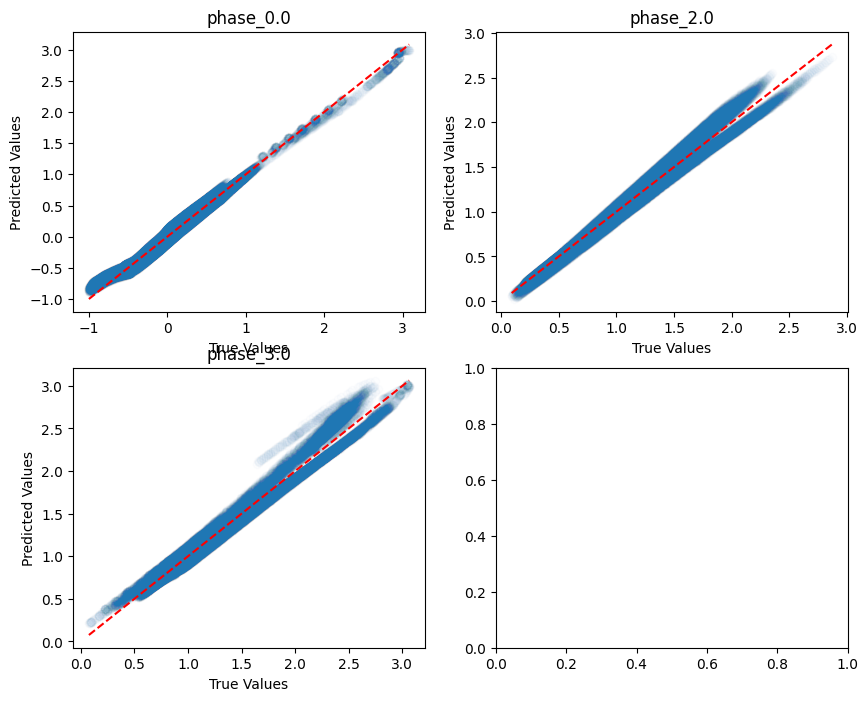

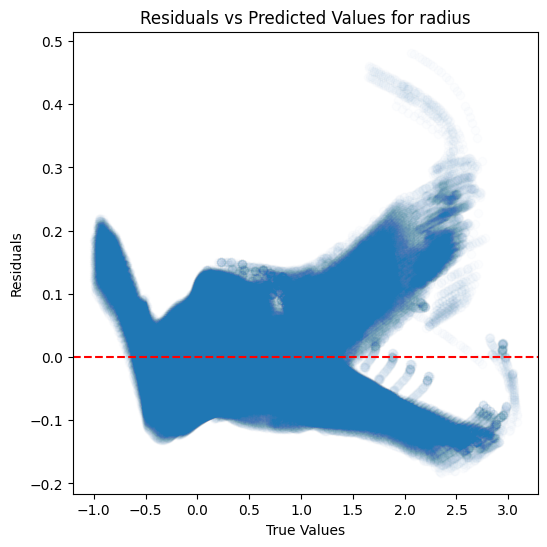

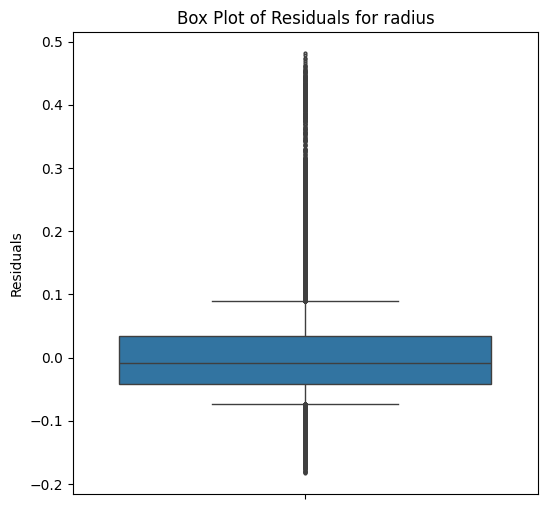

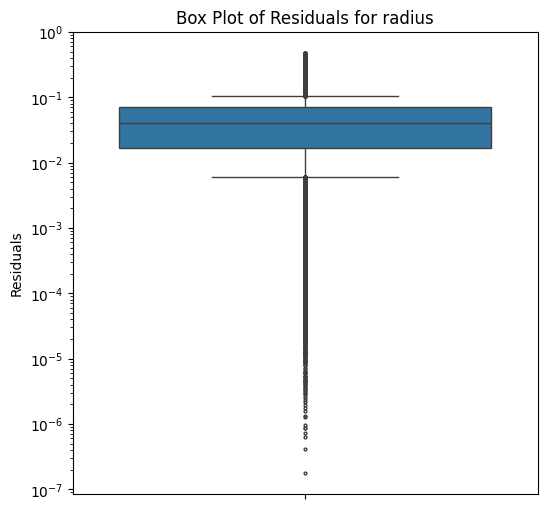

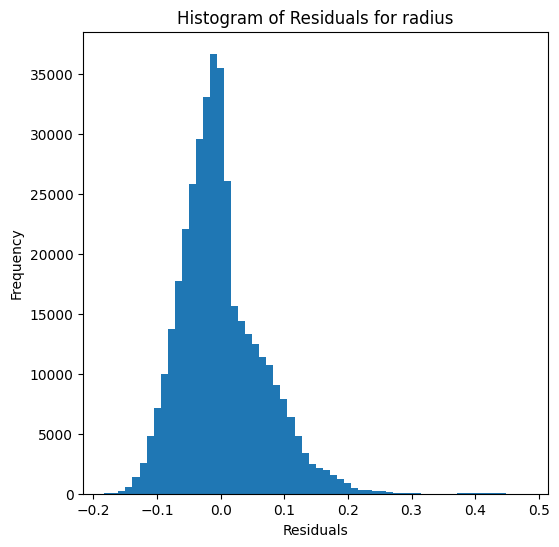

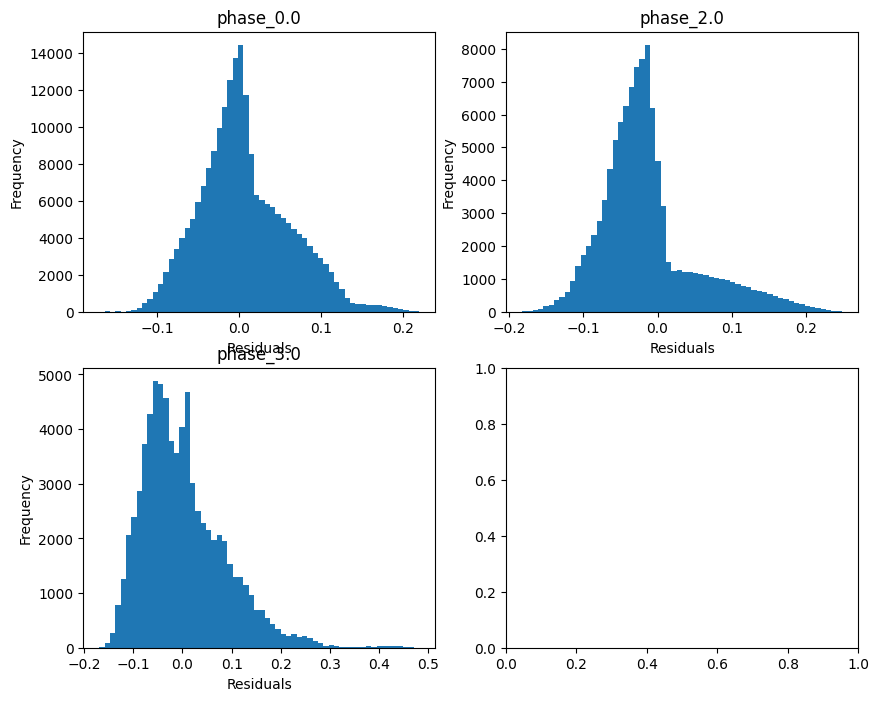

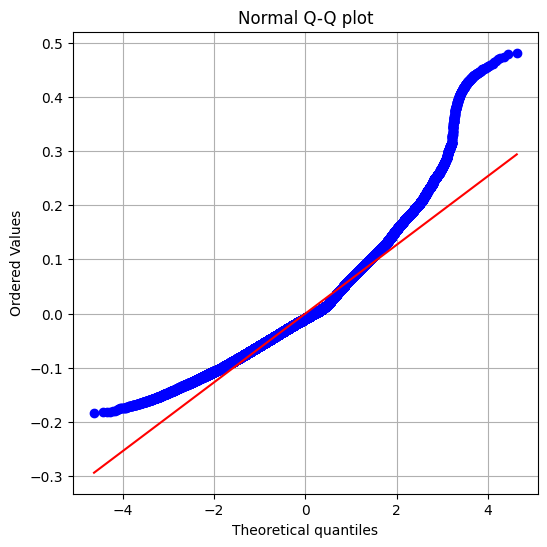

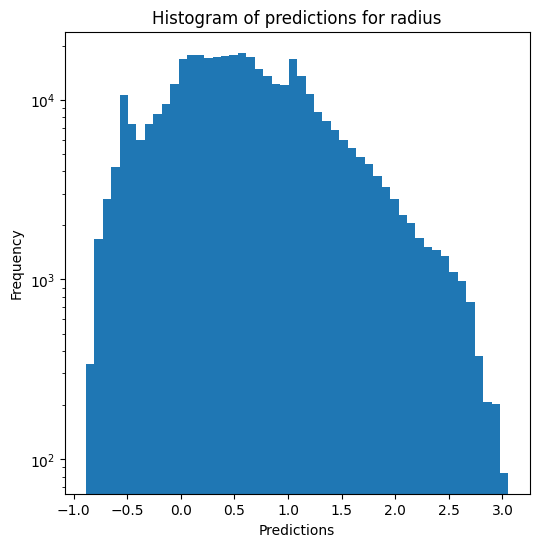

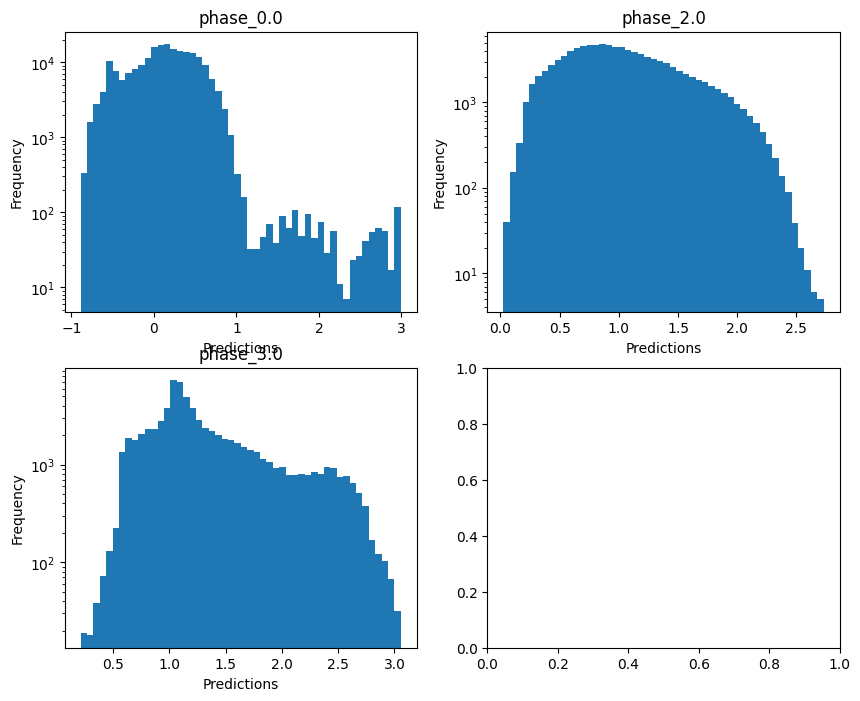

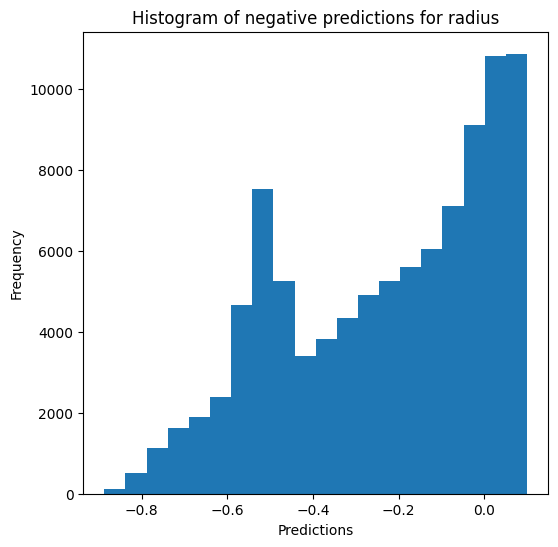

Saving predictions and results...


In [11]:
lr_evaluator.evaluate_Kfold_results(LinearRegression, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name) #, override=False, use_preds=True

### Decision tree

In [12]:
dt_evaluator = Model_evaluator("decision_tree", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997543696077013
  RMSE :  0.051648738146218086
  MAE :  0.01697022097686398
  MedAE :  0.004126010992542728
  CORR :  0.9998771813410589
  MAX_ER :  5.116395062787612
  Percentiles : 
    75th percentile :  0.01363872424911694
    90th percentile :  0.04199837909656008
    95th percentile :  0.07389587729084801
    99th percentile :  0.19522713926699153

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999399369641745
  RMSE :  0.025184076312126
  MAE :  0.007691418555852532
  MedAE :  0.0003258286741218974
  CORR :  0.9999701104569542
  MAX_ER :  1.4104238006648107
  Percentiles : 
    75th percentile :  0.005782722245951333
    90th percentile :  0.02327405575535309
    95th percent

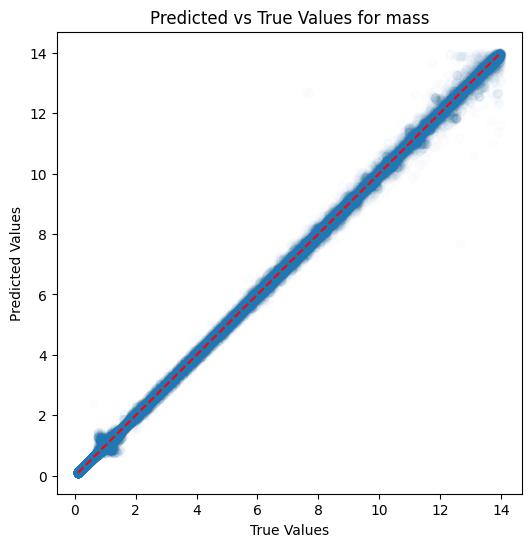

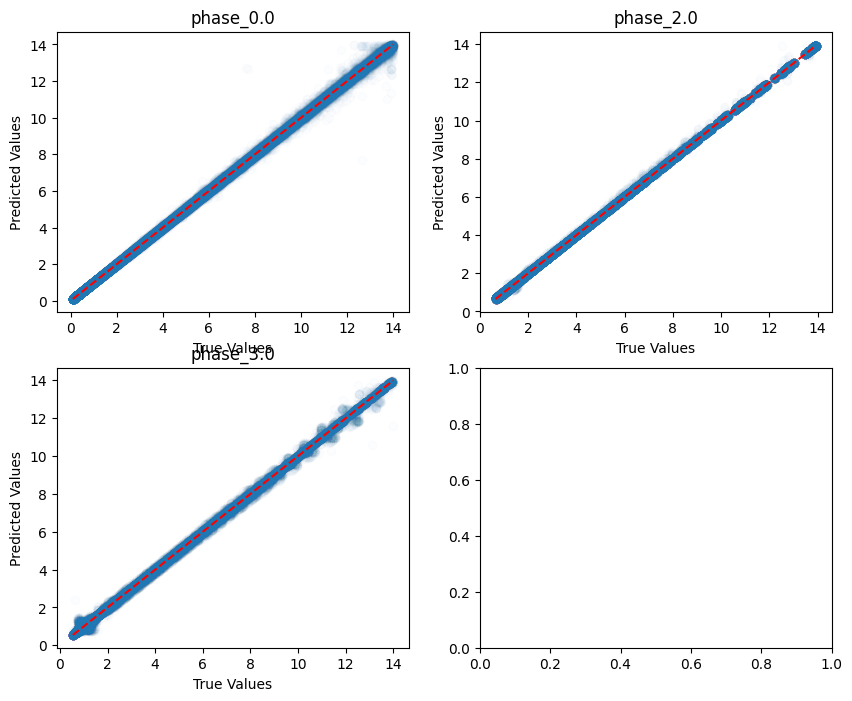

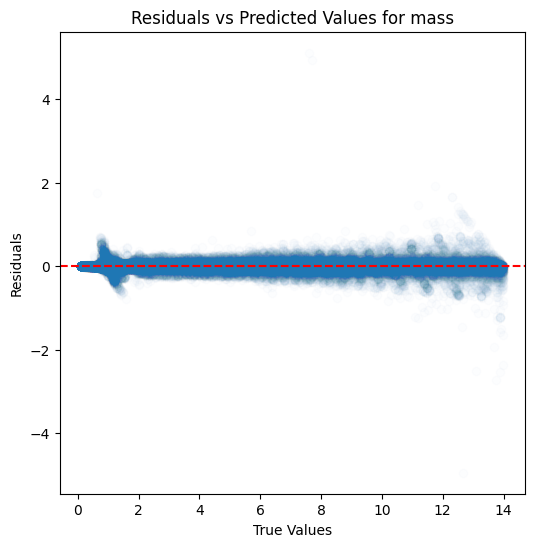

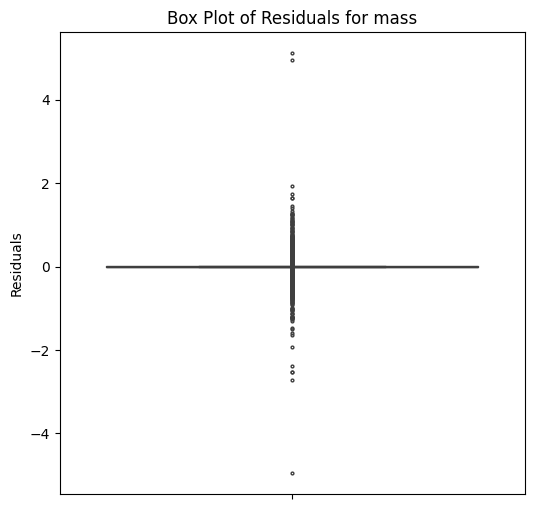

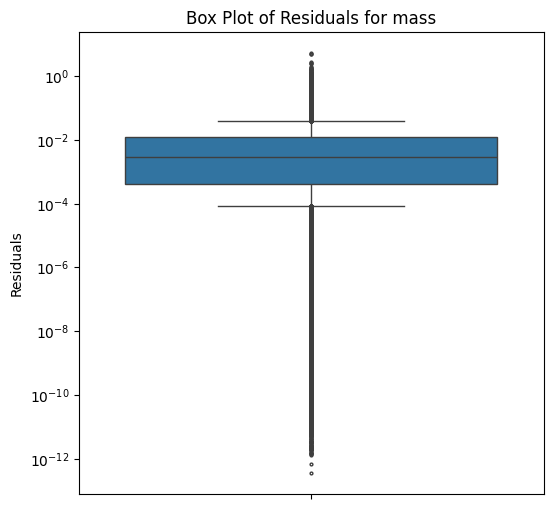

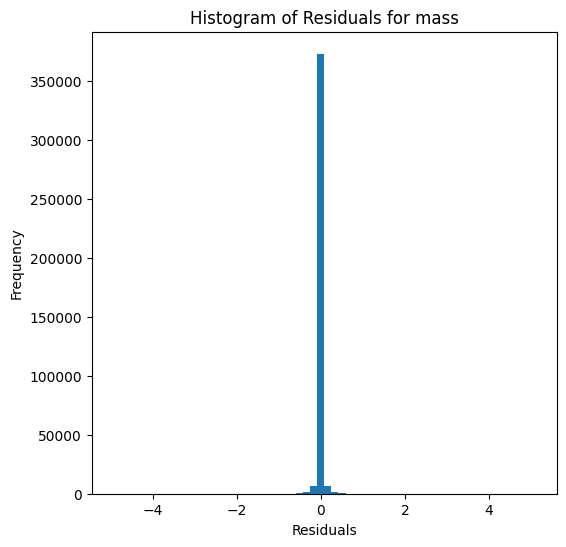

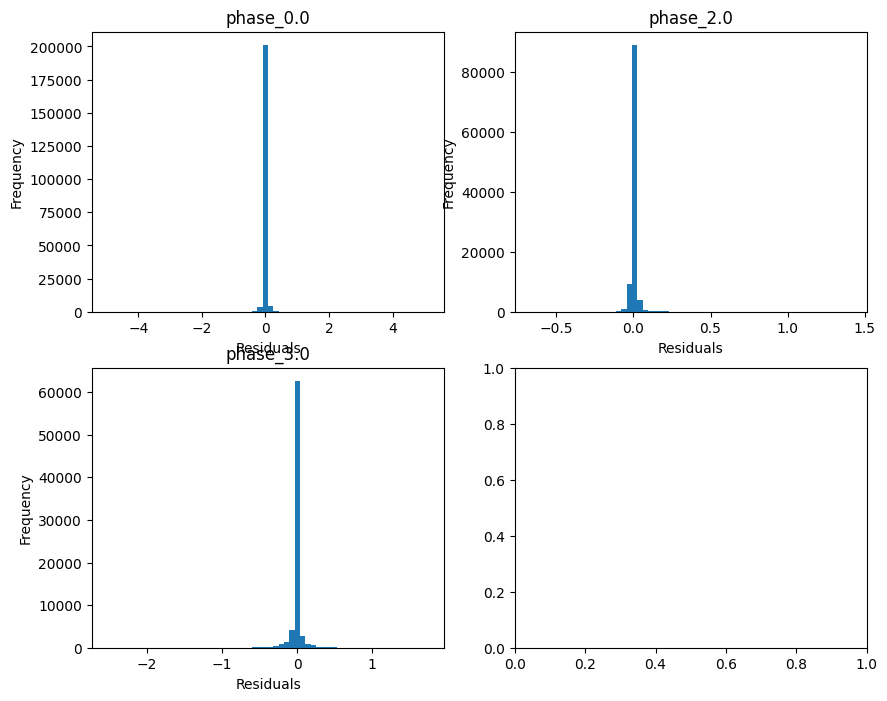

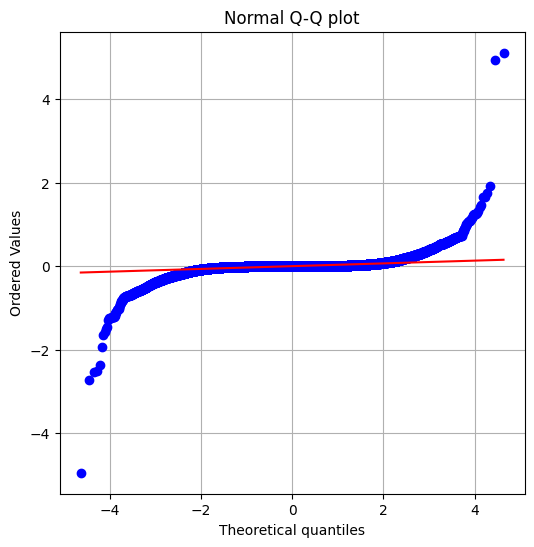

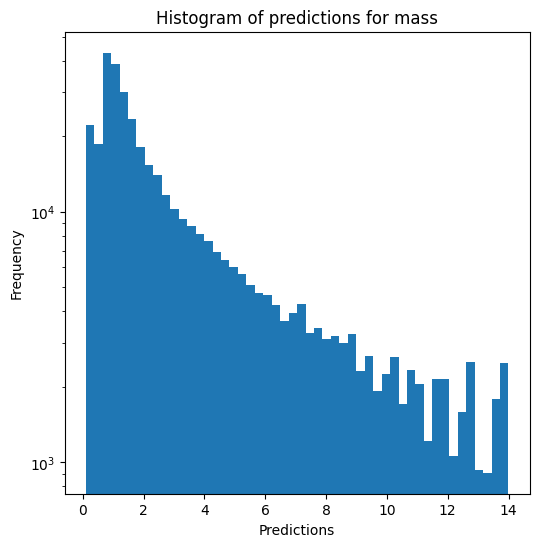

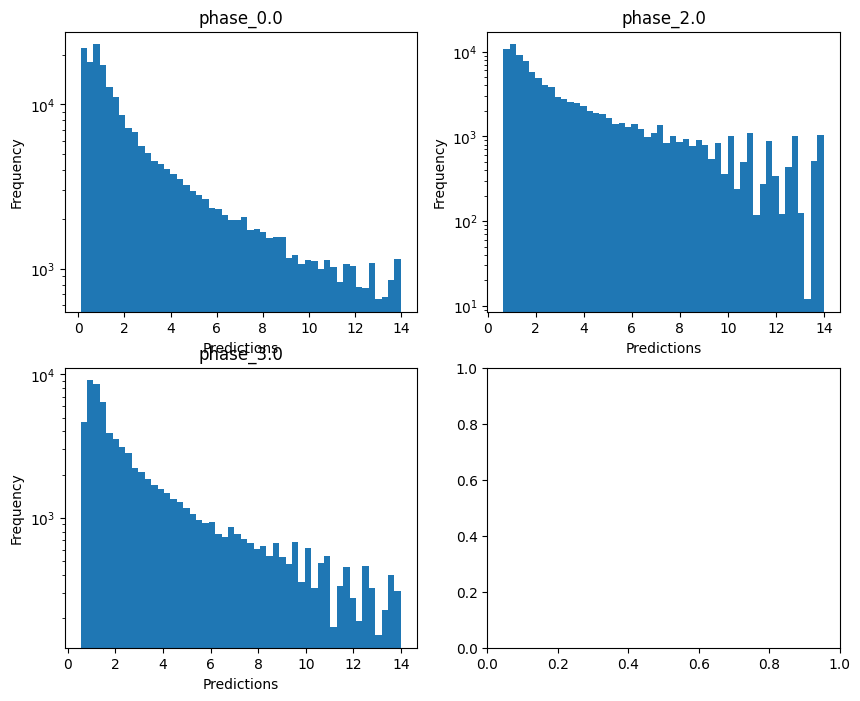

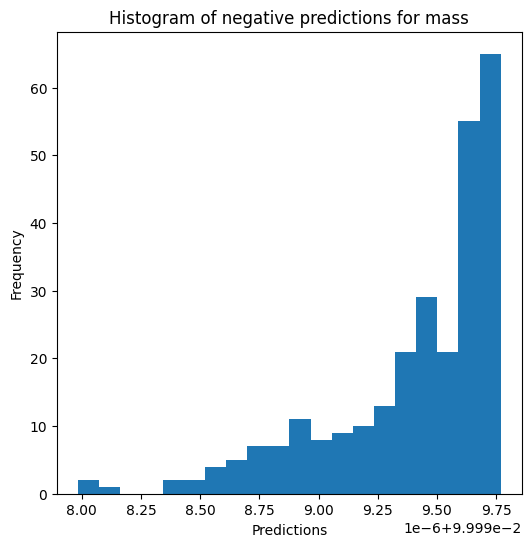


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9997870210790004
  RMSE :  0.00615163273468161
  MAE :  0.0036329790186521425
  MedAE :  0.002283471598593878
  CORR :  0.999893506751041
  MAX_ER :  0.31869682061915194
  Percentiles : 
    75th percentile :  0.0045597282791859
    90th percentile :  0.008030021693670487
    95th percentile :  0.01130242576599525
    99th percentile :  0.023704333811028832

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9995081235141497
  RMSE :  0.010333272314292612
  MAE :  0.0073315664773974335
  MedAE :  0.006022490469735187
  CORR :  0.9997561510452599
  MAX_ER :  0.3767123245315078
  Percentiles : 
    75th percentile :  0.009803792928581523
    90th percentile :  0.013832893335192456
    95th percentile :  0.017259013232024275
    99th percentile :  0.03237551253514919

radius results for the

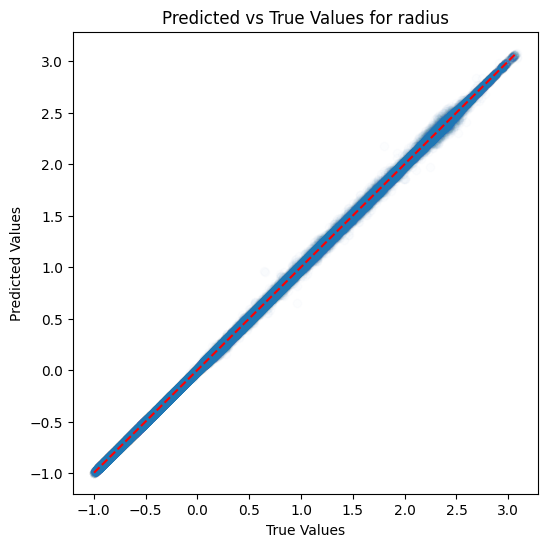

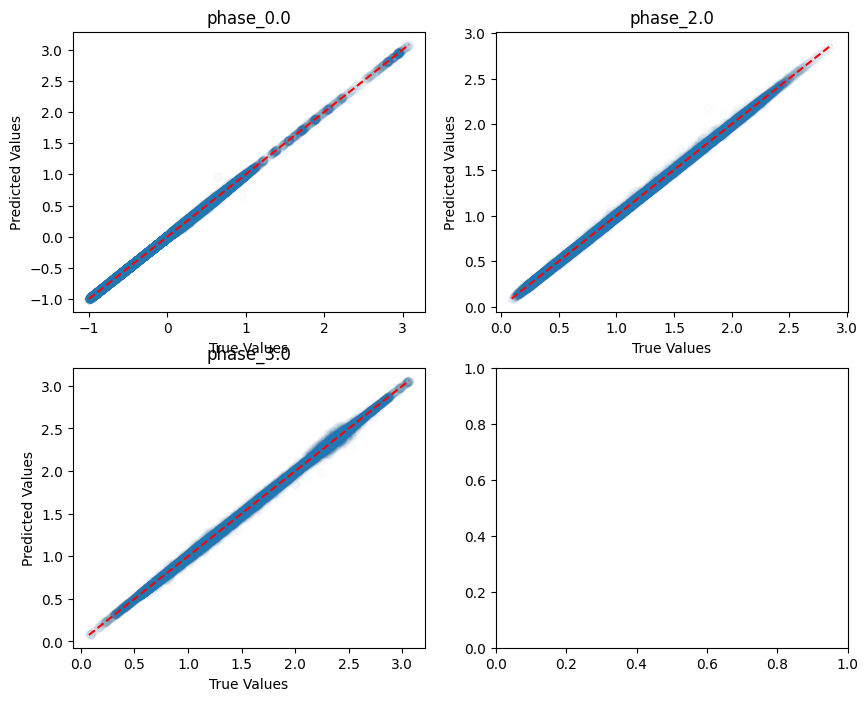

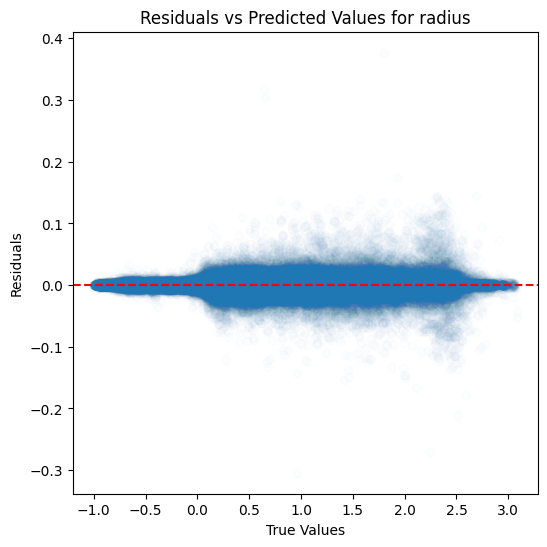

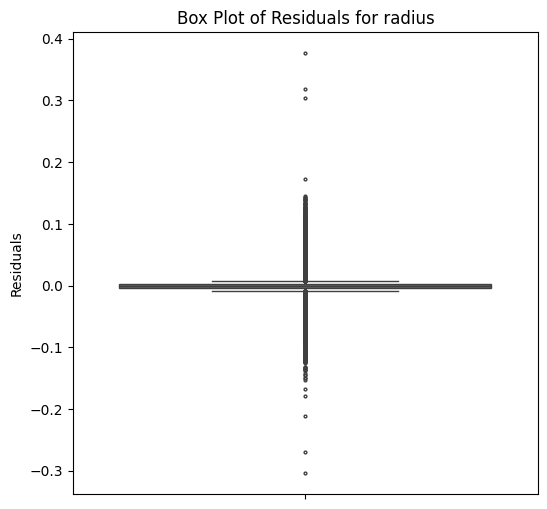

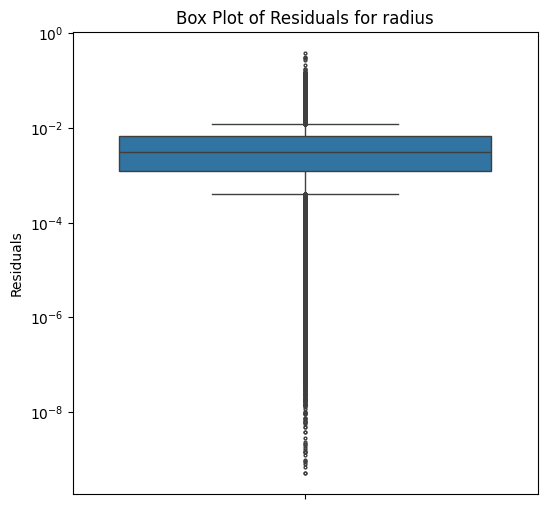

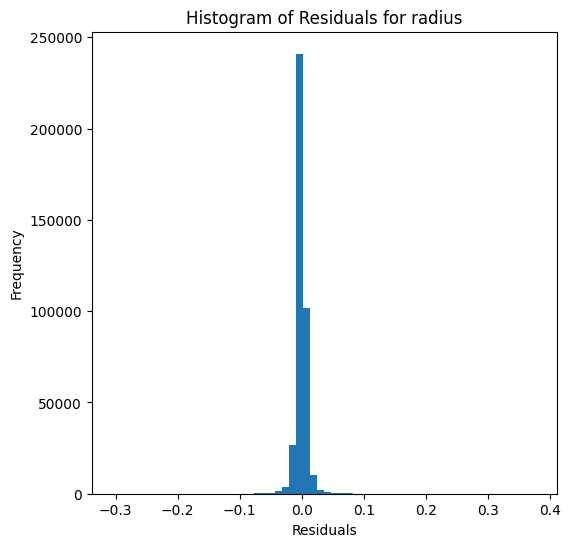

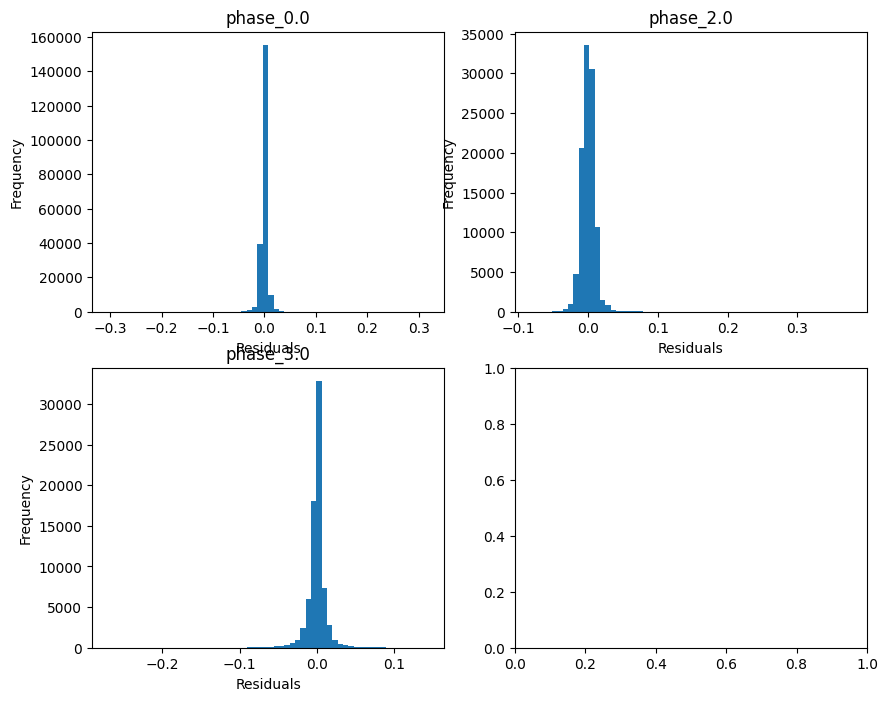

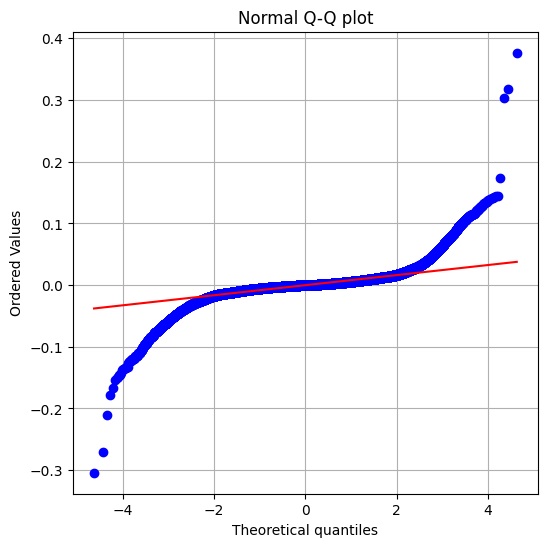

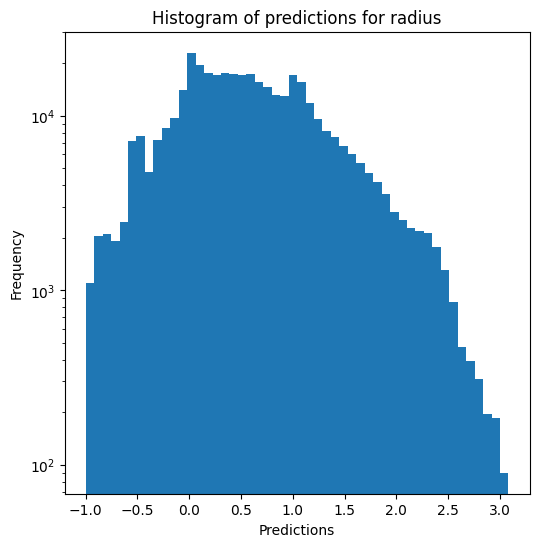

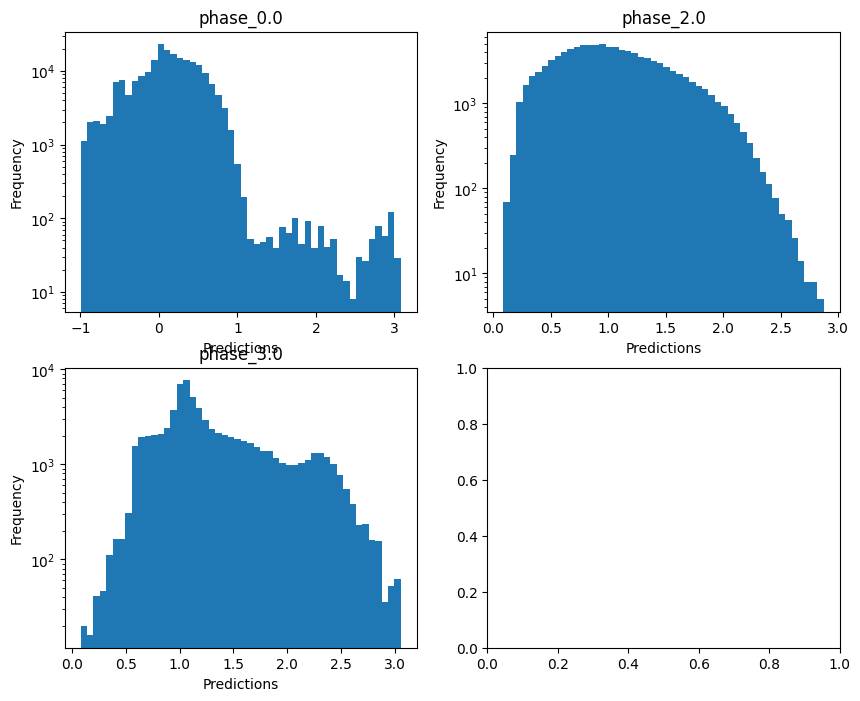

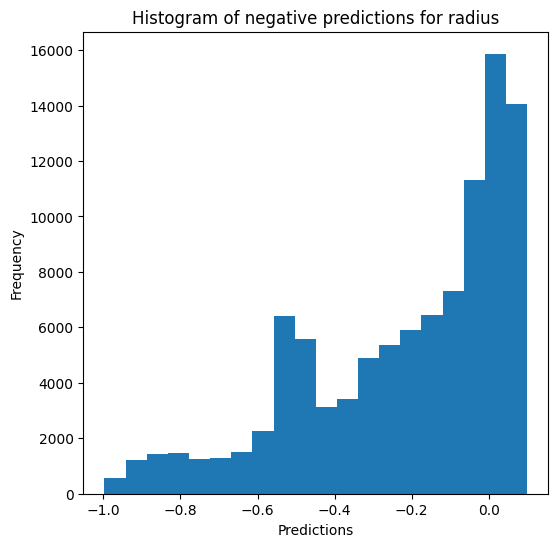

Saving predictions and results...


In [13]:
dt_evaluator.evaluate_Kfold_results(DecisionTreeRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### K-nearest neighbours

In [14]:
knn_evaluator = Model_evaluator("KNN", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...
no negative values

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997604846781156
  RMSE :  0.05100689195161657
  MAE :  0.019722372002398476
  MedAE :  0.005058284093935939
  CORR :  0.9998812431643301
  MAX_ER :  2.609913223882849
  Percentiles : 
    75th percentile :  0.016618369056292437
    90th percentile :  0.05152002507995965
    95th percentile :  0.0910211148594253
    99th percentile :  0.21227192495106775

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997414462054591
  RMSE :  0.052235982752619904
  MAE :  0.019928753277560014
  MedAE :  0.004599854609508958
  CORR :  0.9998720876755861
  MAX_ER :  0.984844261976372
  Percentiles : 
    75th percentile :  0.014516992628161085
    90th percentile :  0.05556441759714

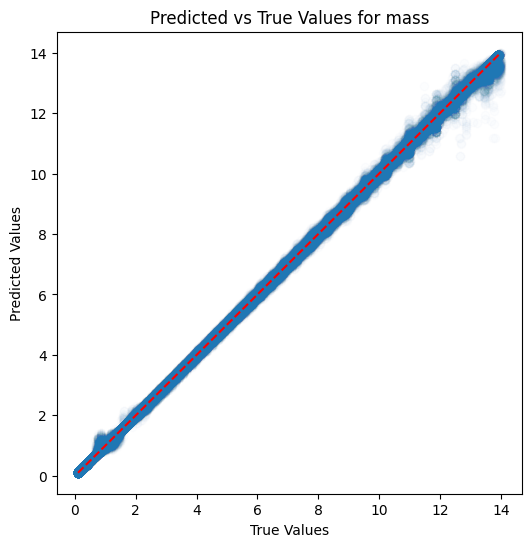

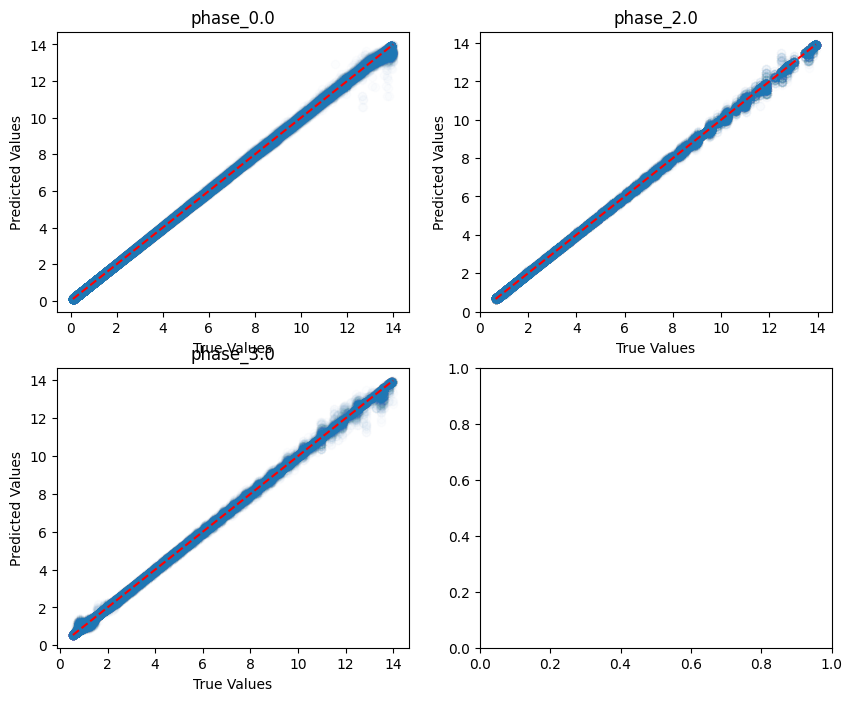

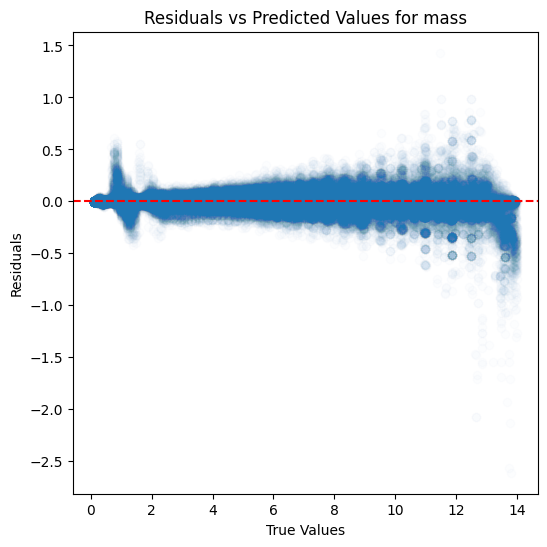

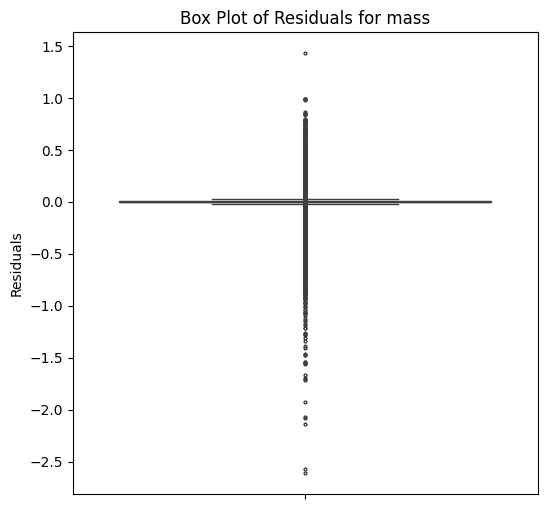

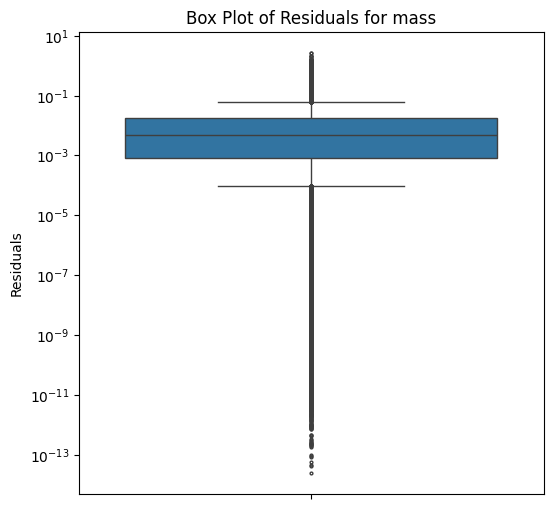

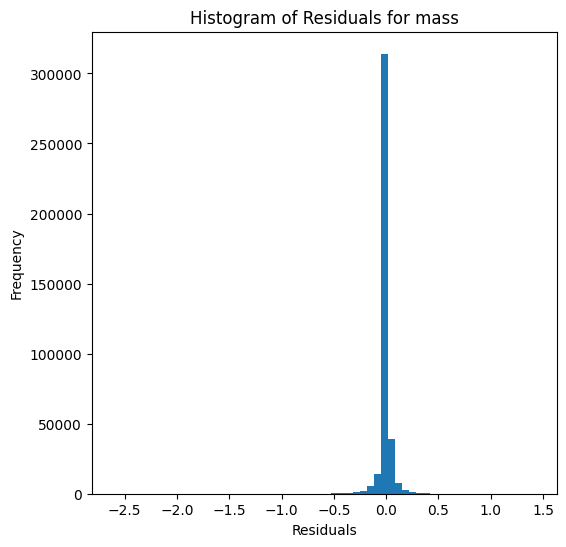

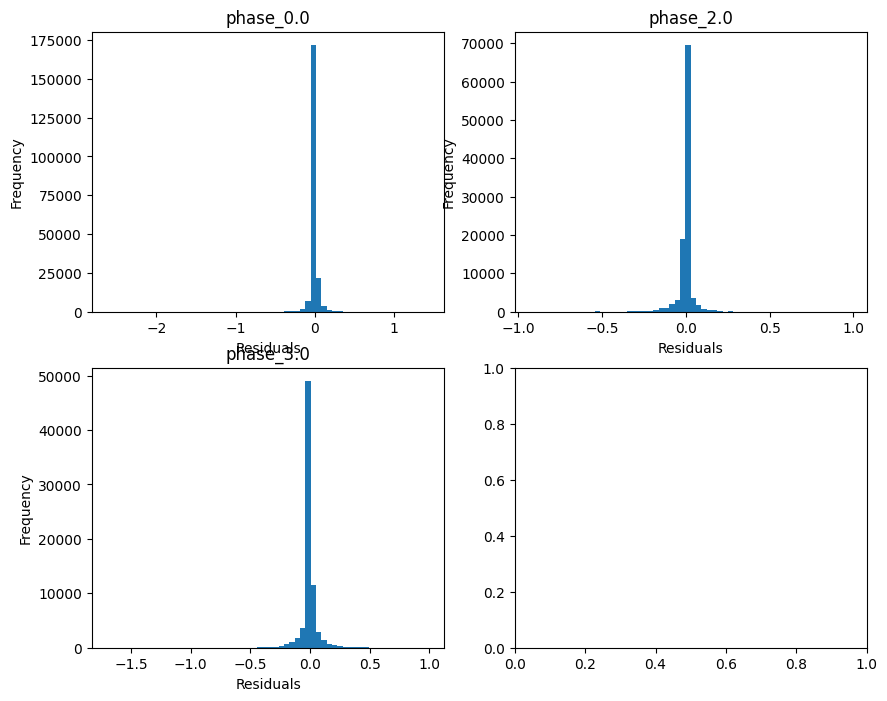

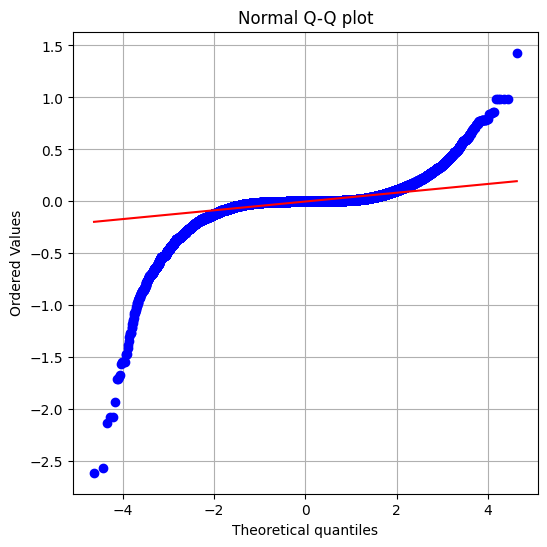

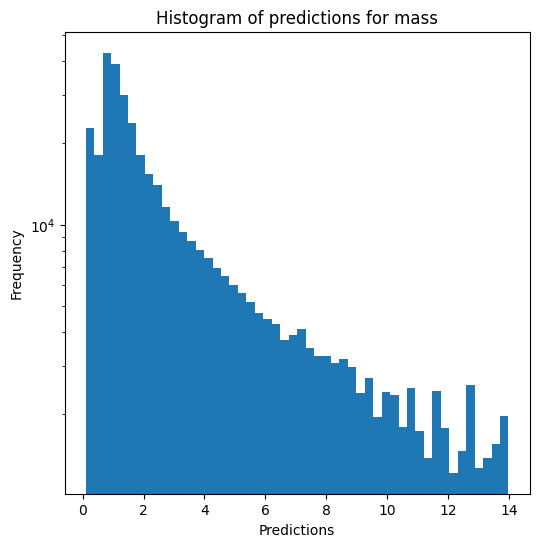

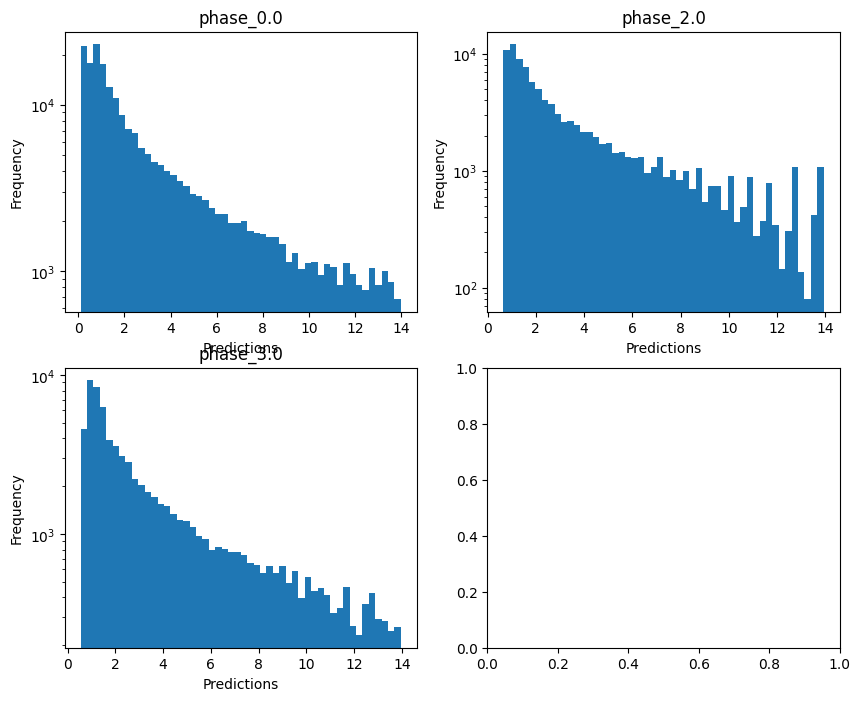


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9998820642446323
  RMSE :  0.004574890885713205
  MAE :  0.0030562207647391875
  MedAE :  0.0020921652065087892
  CORR :  0.9999414092228709
  MAX_ER :  0.05764616047952276
  Percentiles : 
    75th percentile :  0.003883193992973044
    90th percentile :  0.006769942319628867
    95th percentile :  0.009281570100823453
    99th percentile :  0.016693767148508676

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9998685135767594
  RMSE :  0.005335257751313184
  MAE :  0.004057921058062245
  MedAE :  0.0031846556700206863
  CORR :  0.9999343115494671
  MAX_ER :  0.043294143797743434
  Percentiles : 
    75th percentile :  0.0054845340851999436
    90th percentile :  0.0086696124200915
    95th percentile :  0.010959377662655562
    99th percentile :  0.015879395639765235

radius results

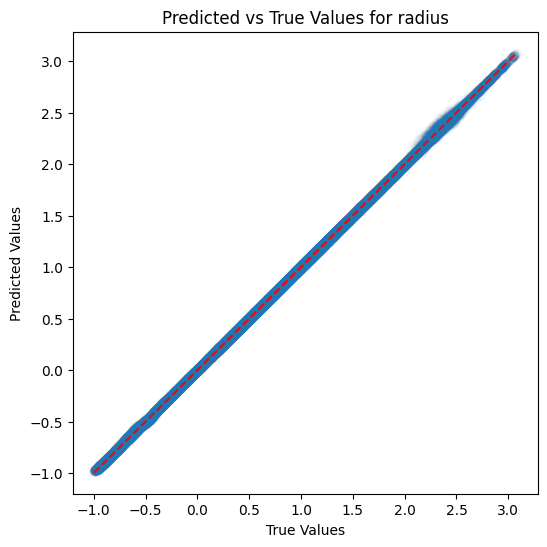

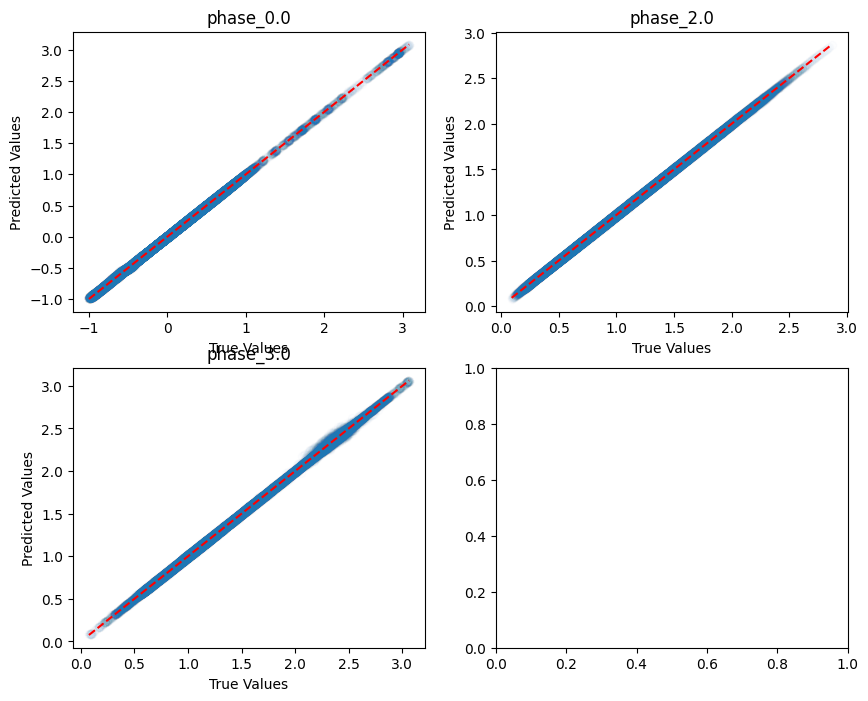

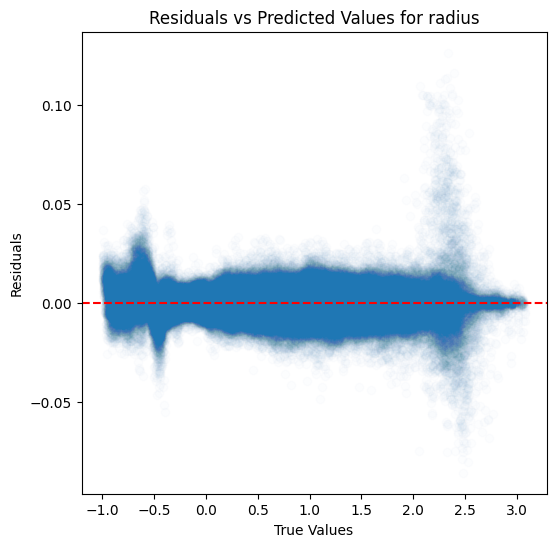

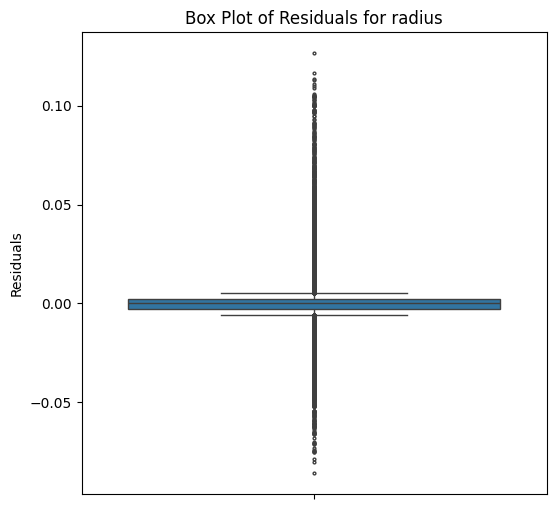

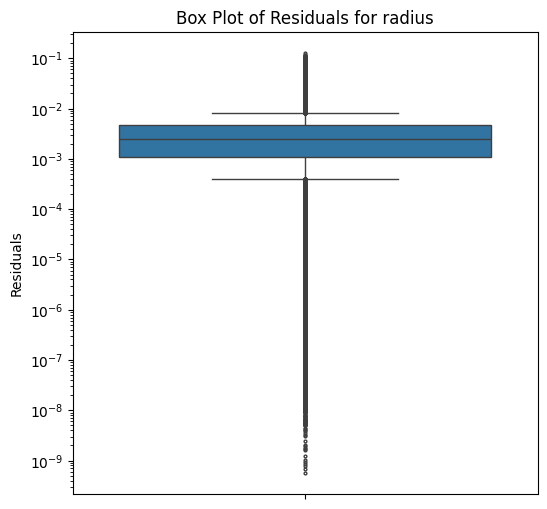

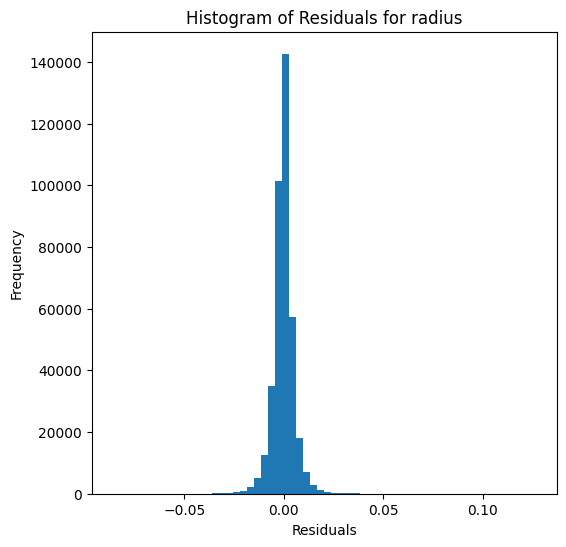

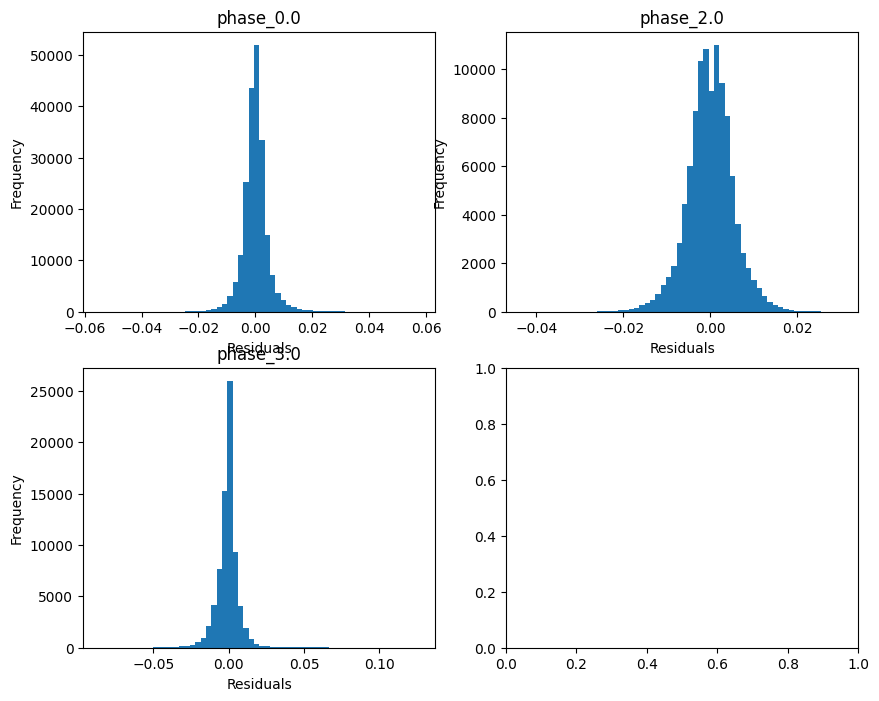

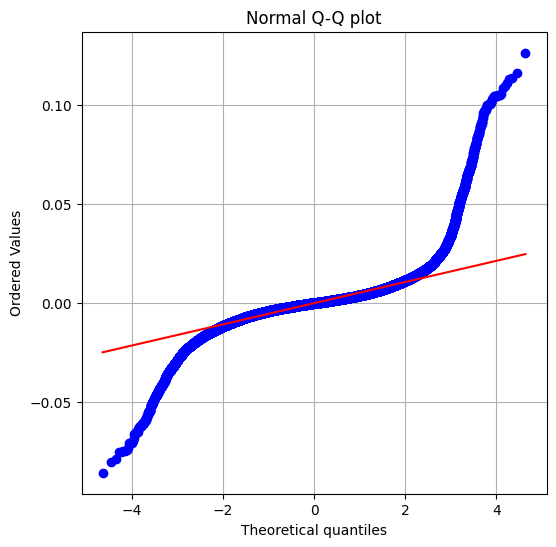

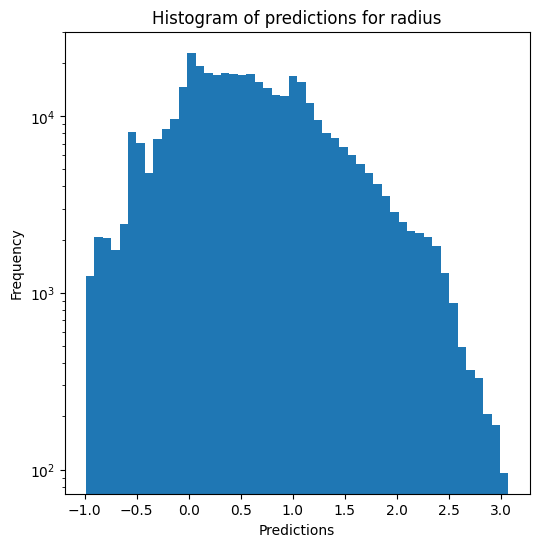

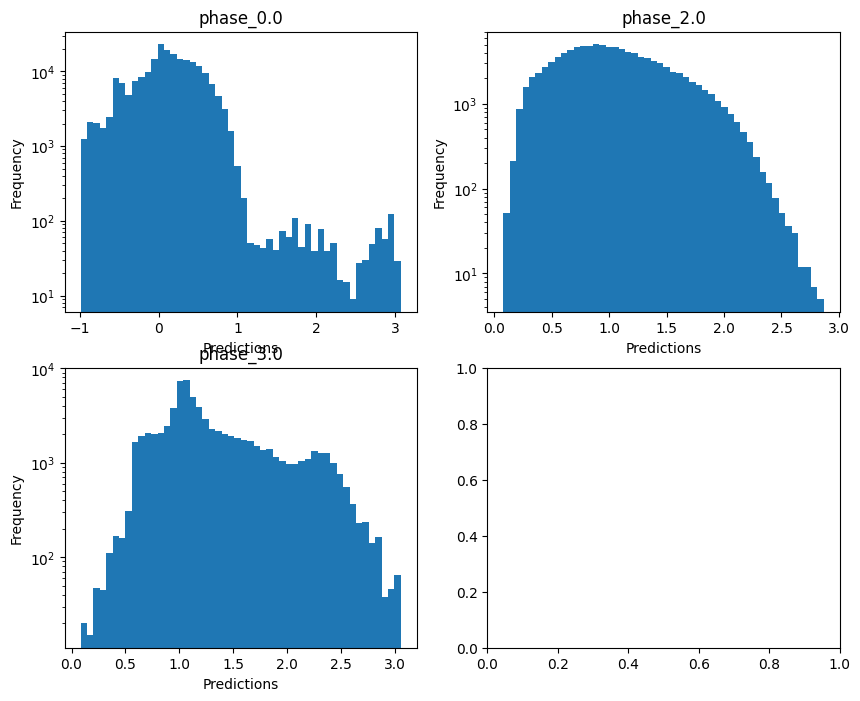

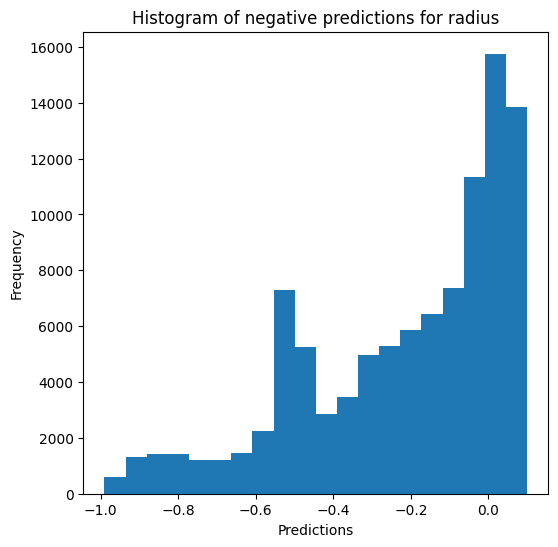

Saving predictions and results...


In [15]:
knn_evaluator.evaluate_Kfold_results(KNeighborsRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name)

### Random forests

In [16]:
rf_evaluator = Model_evaluator("random_forest", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9999224023608961
  RMSE :  0.029030309867779762
  MAE :  0.00881500681183039
  MedAE :  0.002451999025787188
  CORR :  0.9999612124582083
  MAX_ER :  2.3933225440306263
  Percentiles : 
    75th percentile :  0.00719401230571437
    90th percentile :  0.019530743953727562
    95th percentile :  0.034811752727881964
    99th percentile :  0.10175709250433626

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9999734096121519
  RMSE :  0.01683695669732428
  MAE :  0.008439544310224083
  MedAE :  0.0043520786785675725
  CORR :  0.9999868654386693
  MAX_ER :  0.5637996720027001
  Percentiles : 
    75th percentile :  0.010058026206371362
    90th percentile :  0.01887922153820634
    95th pe

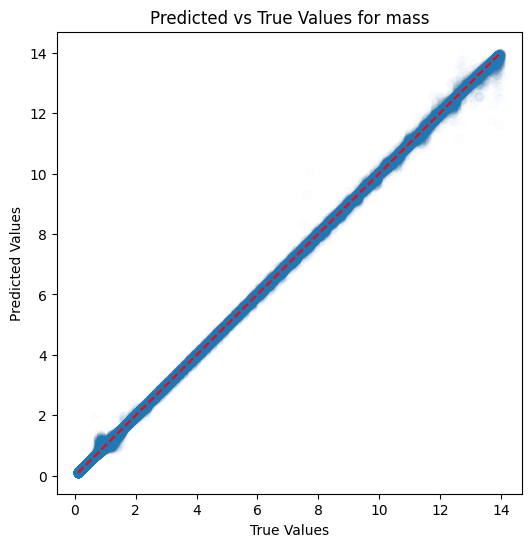

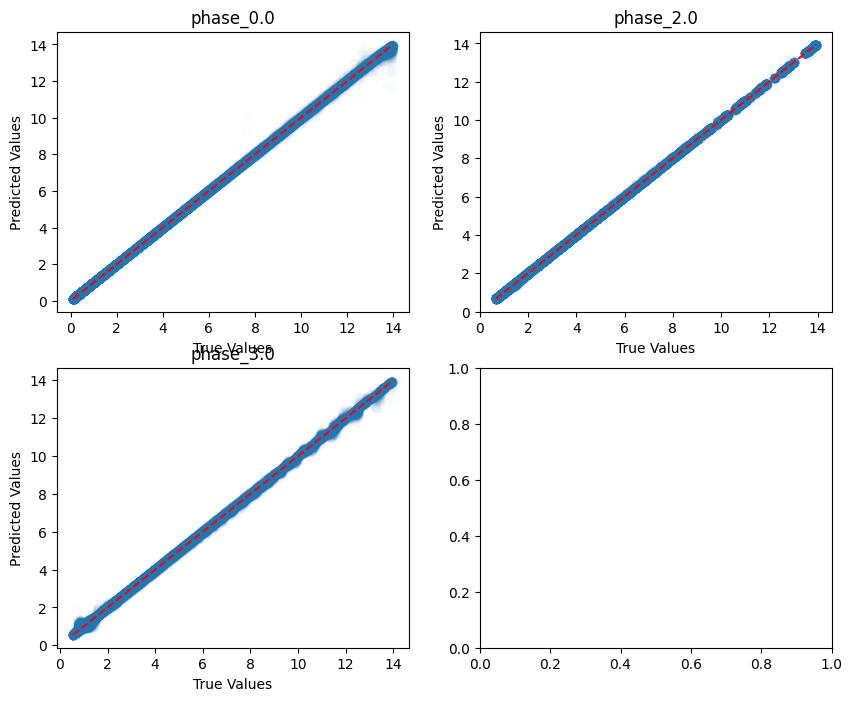

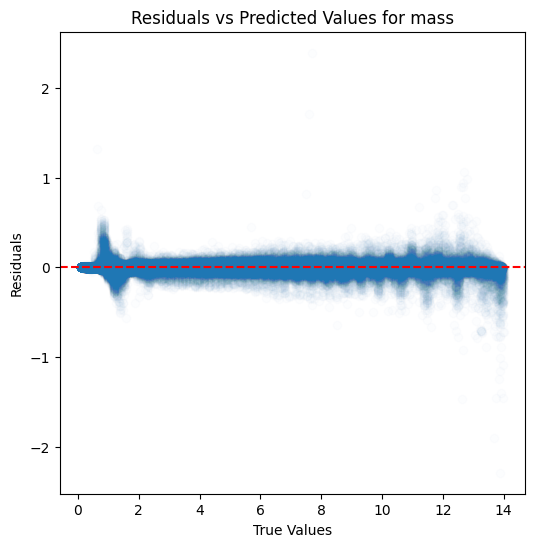

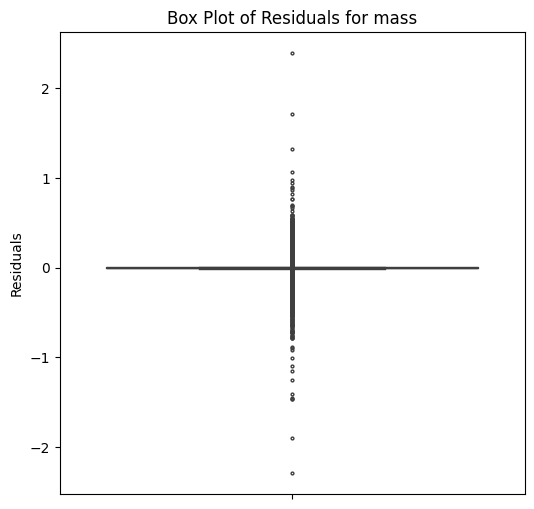

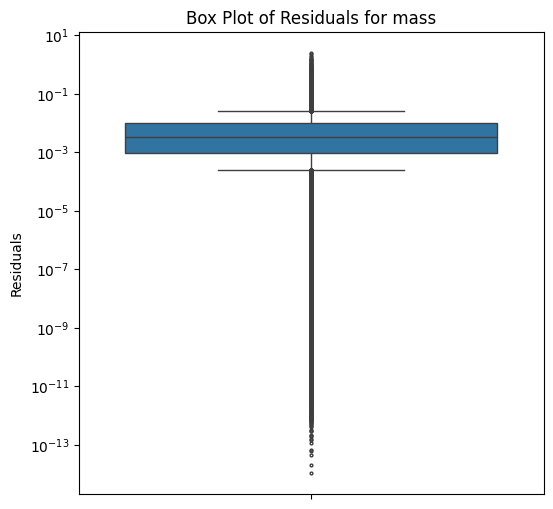

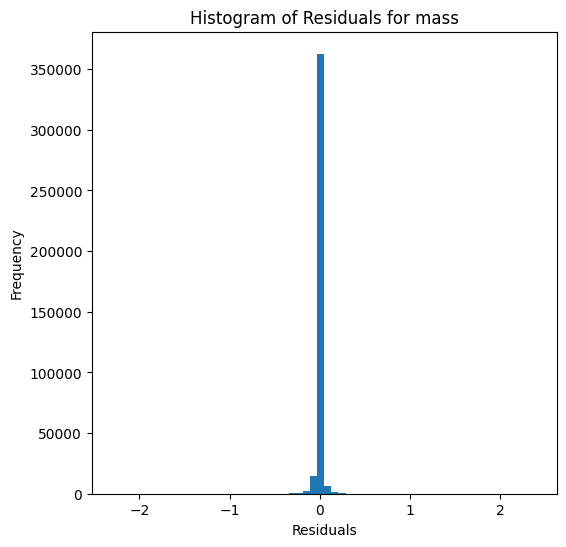

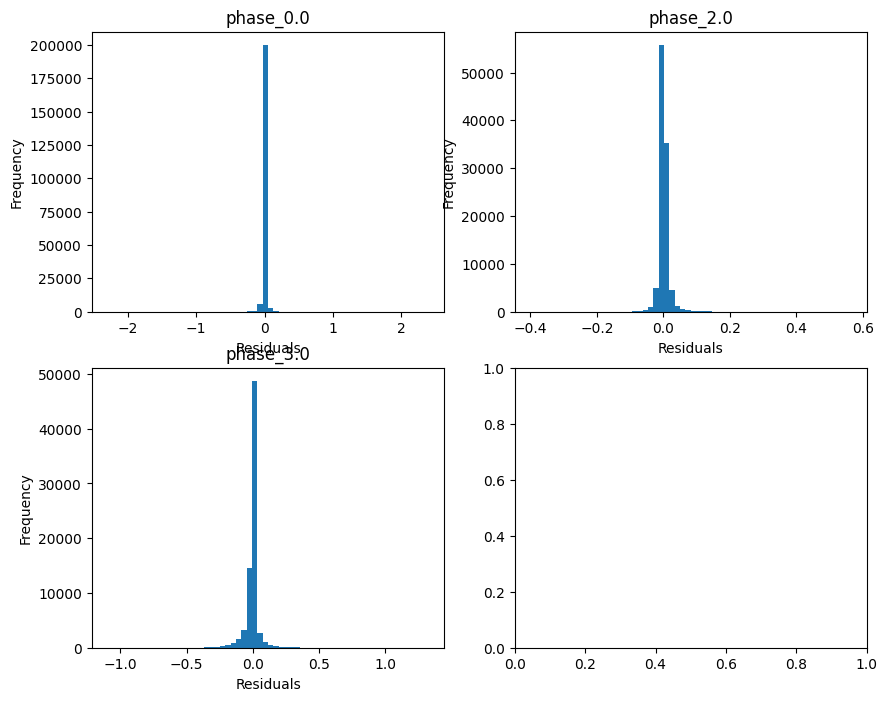

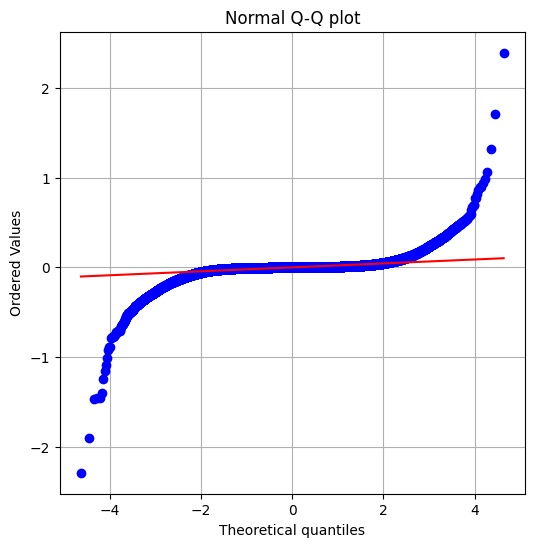

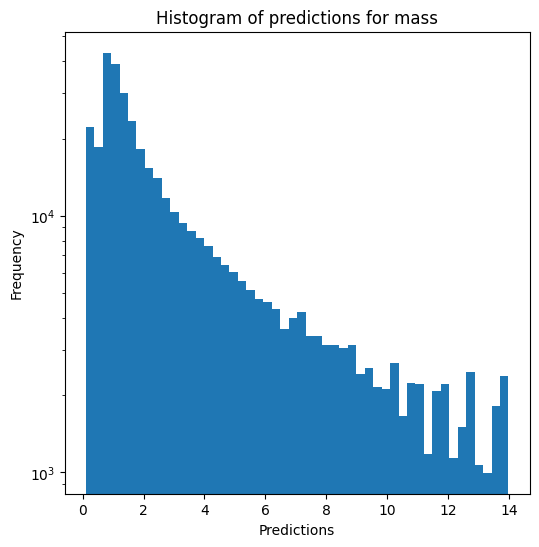

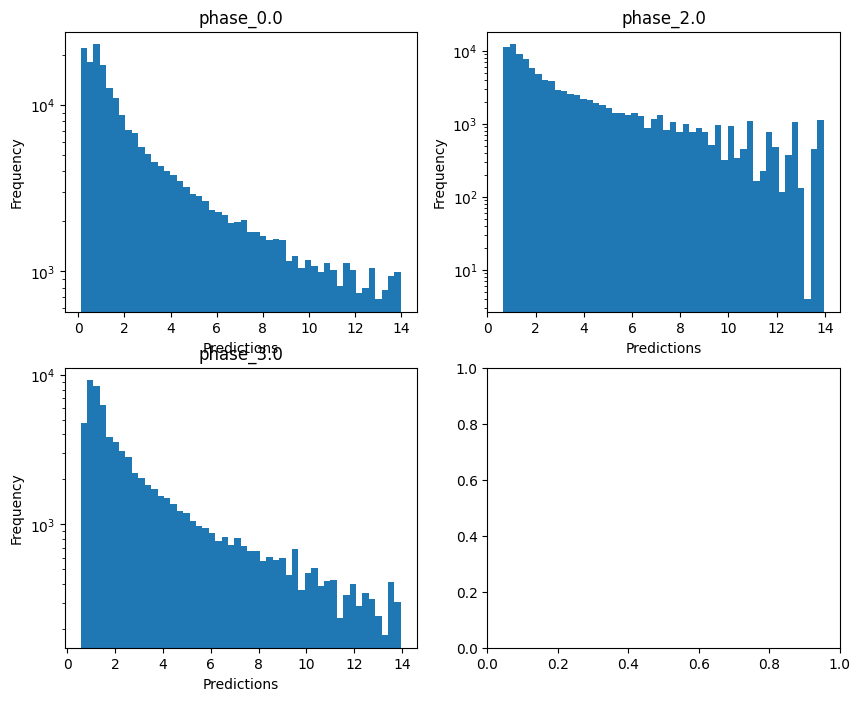

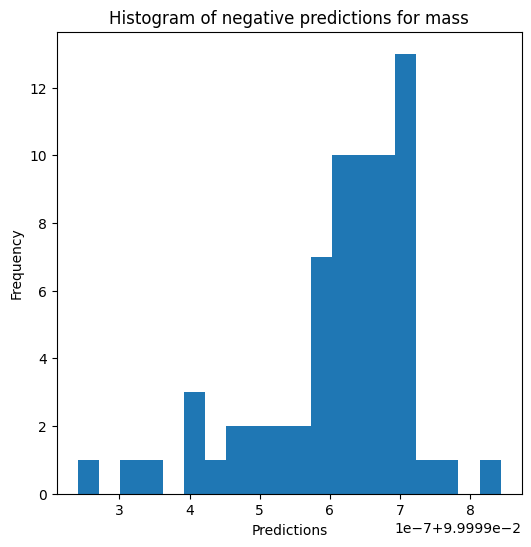


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9999527688109935
  RMSE :  0.0028999458531183742
  MAE :  0.0016327181523143328
  MedAE :  0.0008990447099865573
  CORR :  0.9999764054813925
  MAX_ER :  0.1497611701752627
  Percentiles : 
    75th percentile :  0.0019424499786849236
    90th percentile :  0.0037709382430371474
    95th percentile :  0.005633195503924824
    99th percentile :  0.011445882542506124

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9999182353560526
  RMSE :  0.00425353218234948
  MAE :  0.002922964698257365
  MedAE :  0.001994289810081429
  CORR :  0.999960417365324
  MAX_ER :  0.048854640034260655
  Percentiles : 
    75th percentile :  0.003922711174353166
    90th percentile :  0.006660964314972438
    95th percentile :  0.008778698955622517
    99th percentile :  0.014469838907882825

radius results

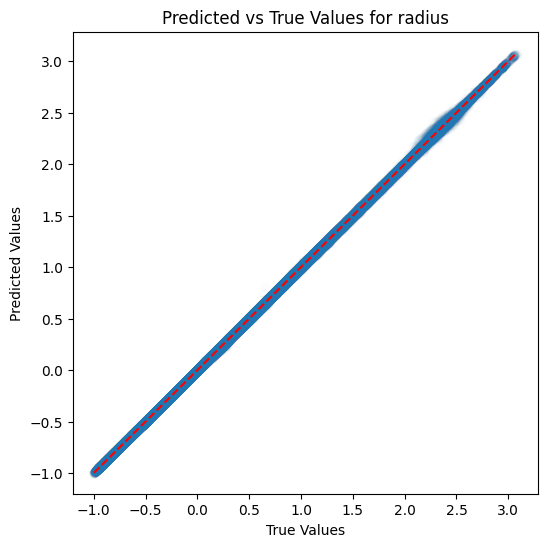

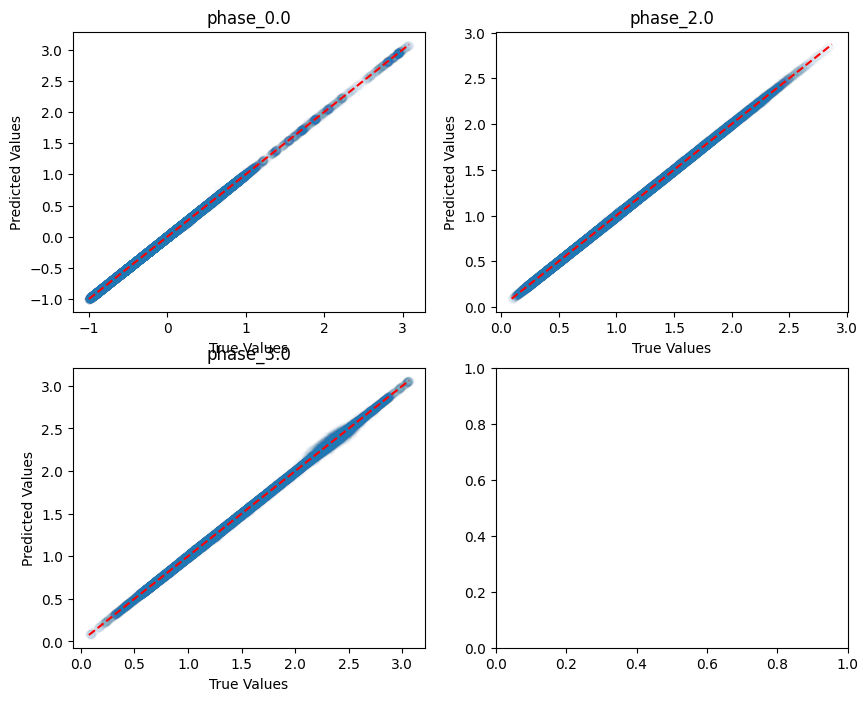

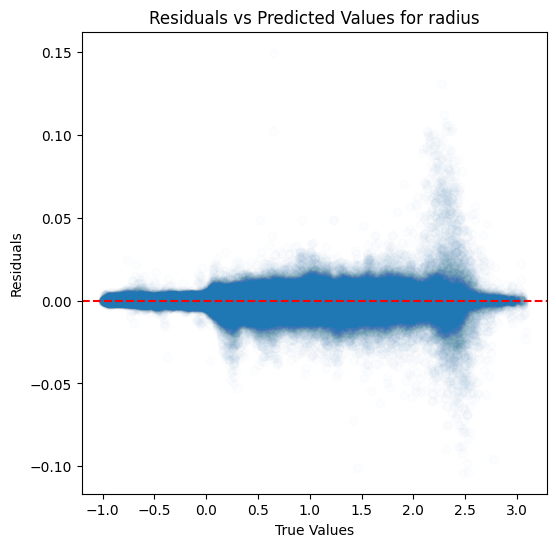

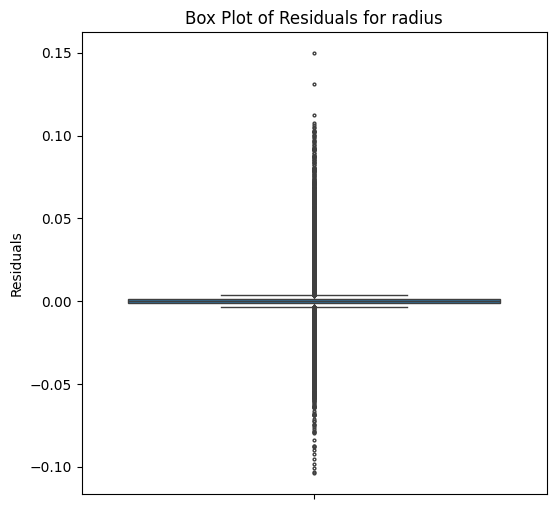

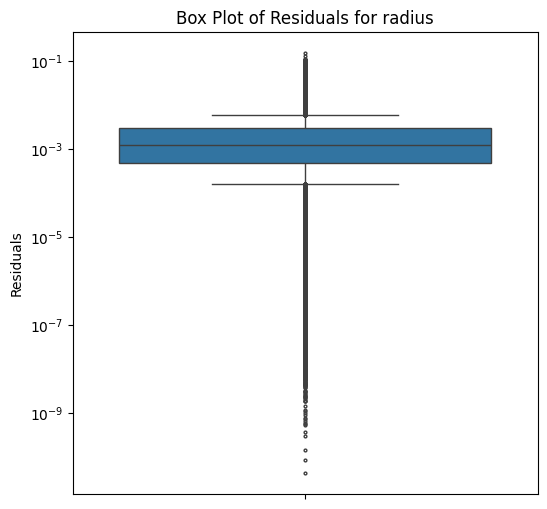

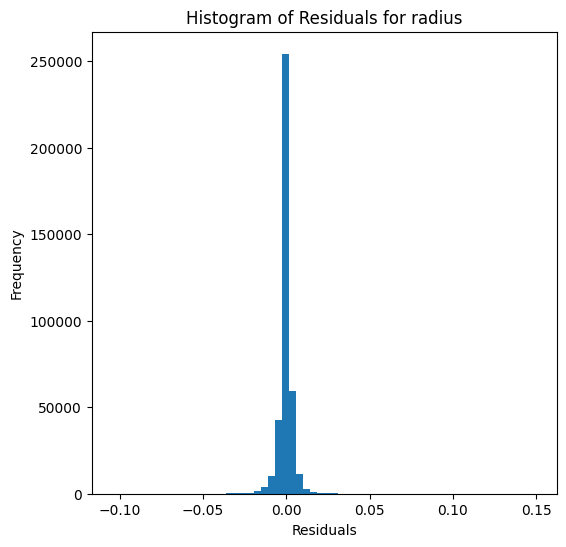

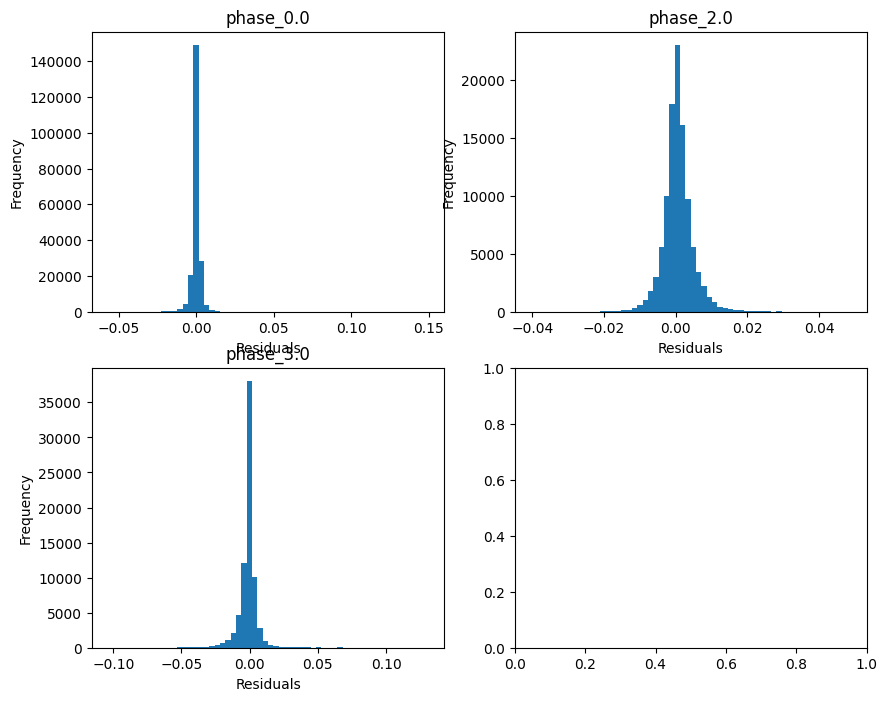

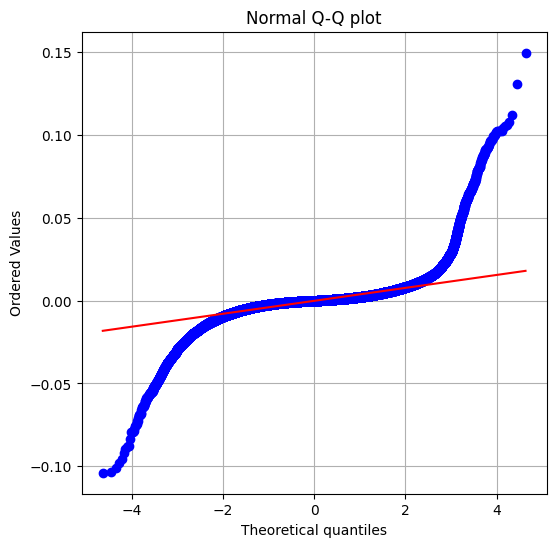

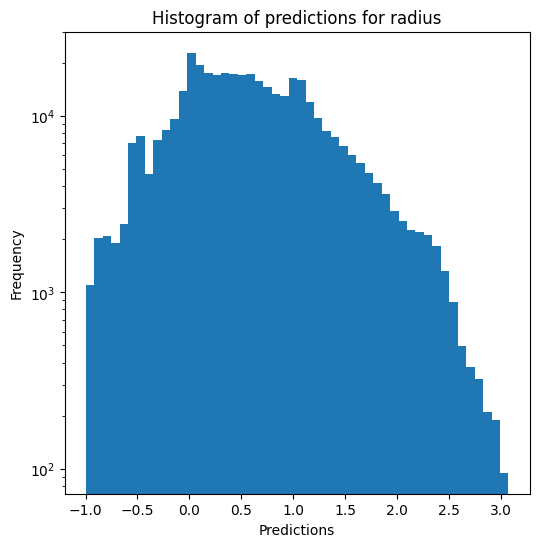

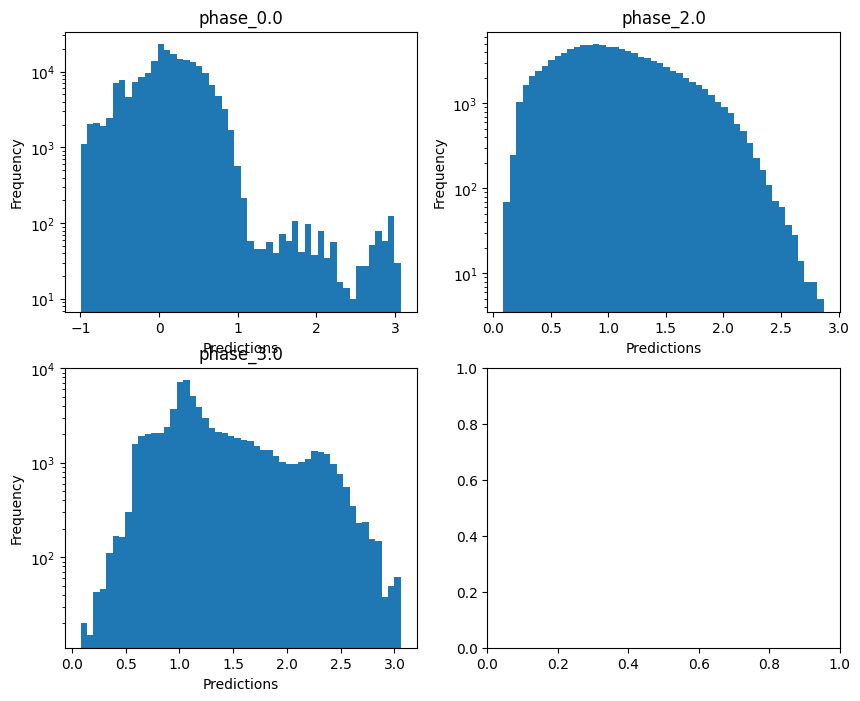

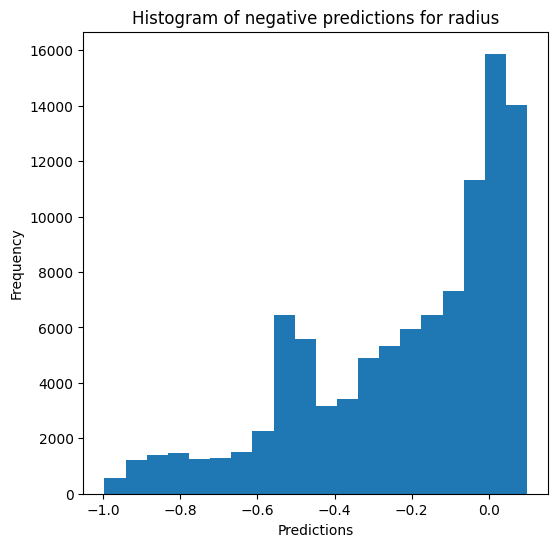

Saving predictions and results...


In [17]:
rf_evaluator.evaluate_Kfold_results(RandomForestRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)
# average depth de 44-46

### XGBoost

In [18]:
xgb_evaluator = Model_evaluator("xgboost", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 2 3 4 5 6 7 8 9 10 
Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9987869036693128
  RMSE :  0.11478241661131876
  MAE :  0.06417742178716188
  MedAE :  0.03178513466183852
  CORR :  0.9993932986617092
  MAX_ER :  2.518844127047103
  Percentiles : 
    75th percentile :  0.07771247375206647
    90th percentile :  0.15714165005349442
    95th percentile :  0.23129342336242176
    99th percentile :  0.4535258110999138

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997533813986034
  RMSE :  0.05288850398468246
  MAE :  0.03605262692319532
  MedAE :  0.023375299841384534
  CORR :  0.9998827280263989
  MAX_ER :  0.642151193964617
  Percentiles : 
    75th percentile :  0.048702756625410015
    90th percentile :  0.08385276899842381
    95th percentile 

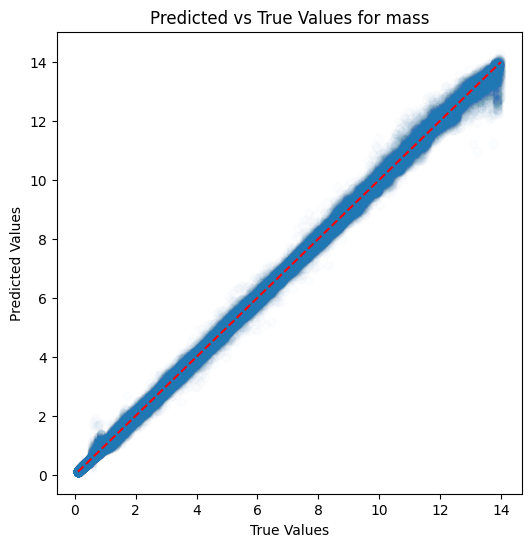

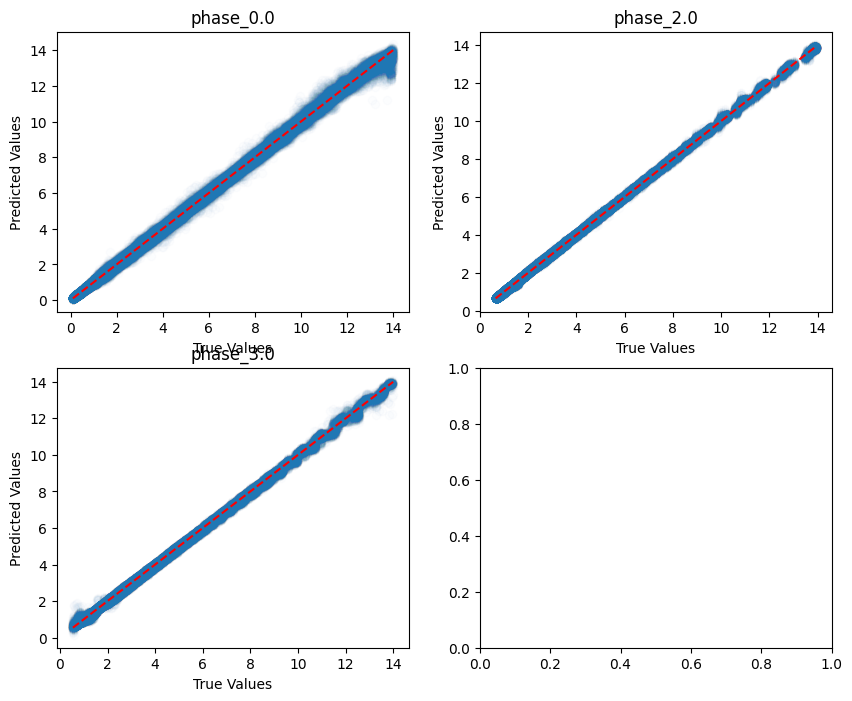

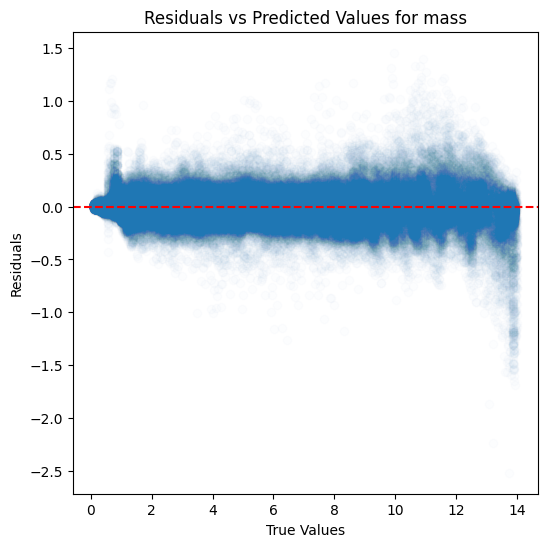

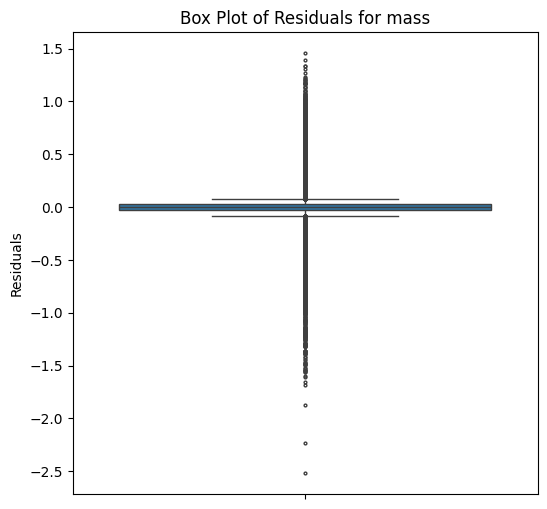

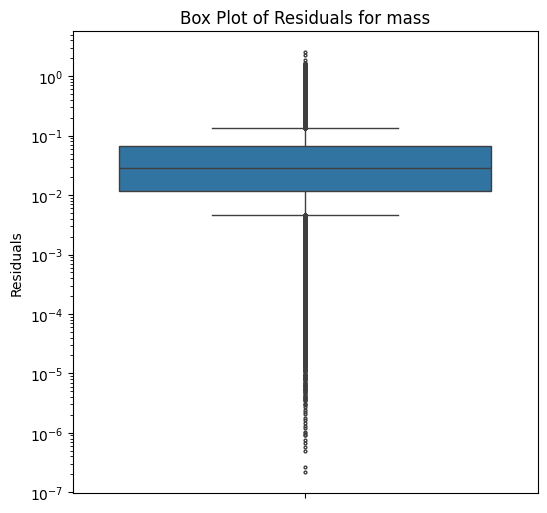

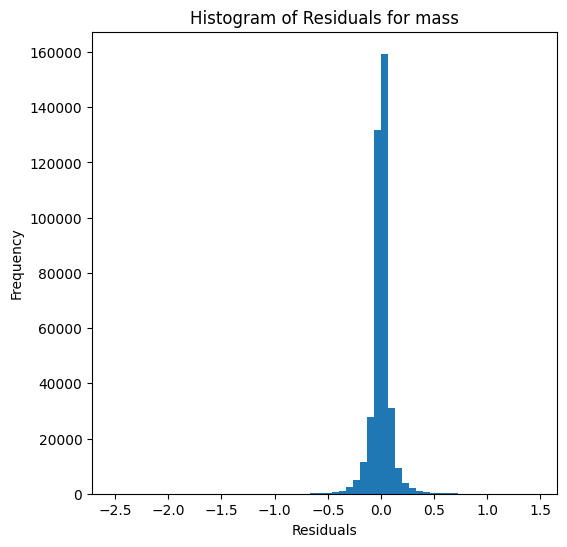

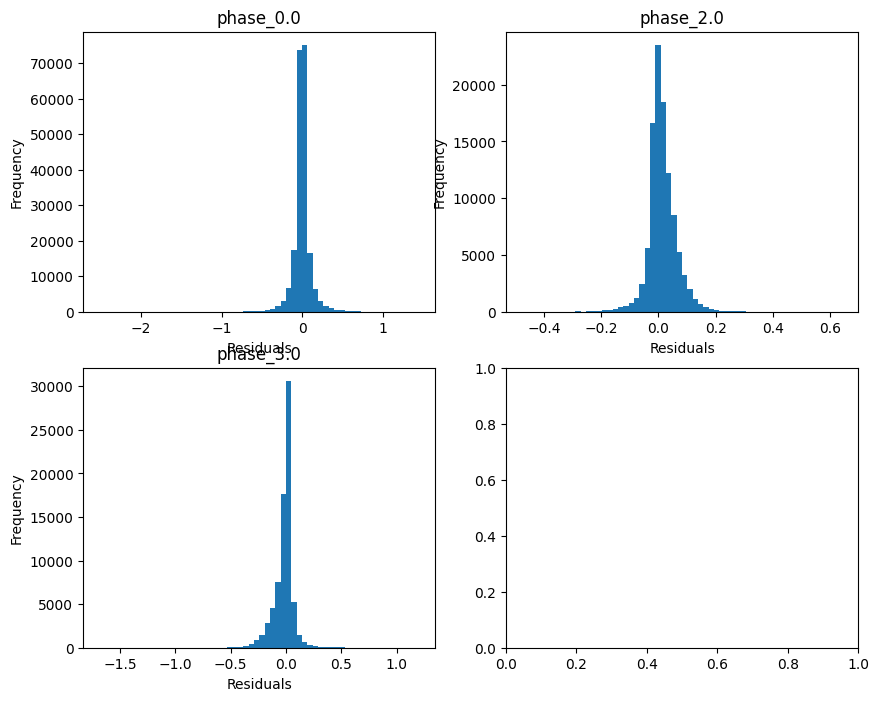

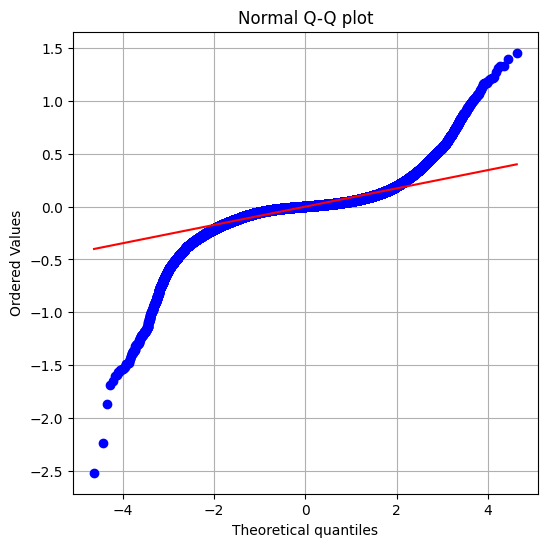

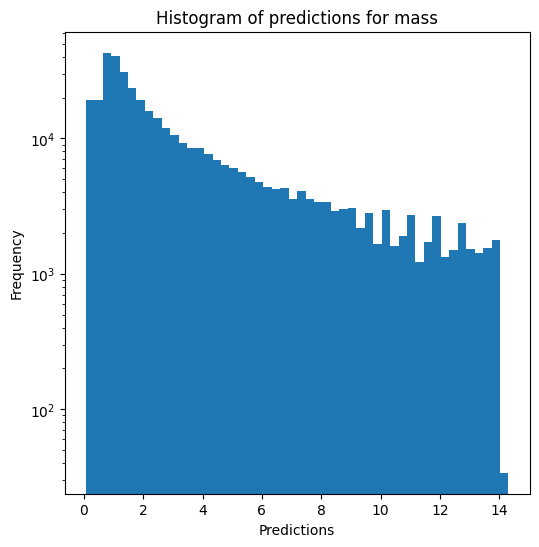

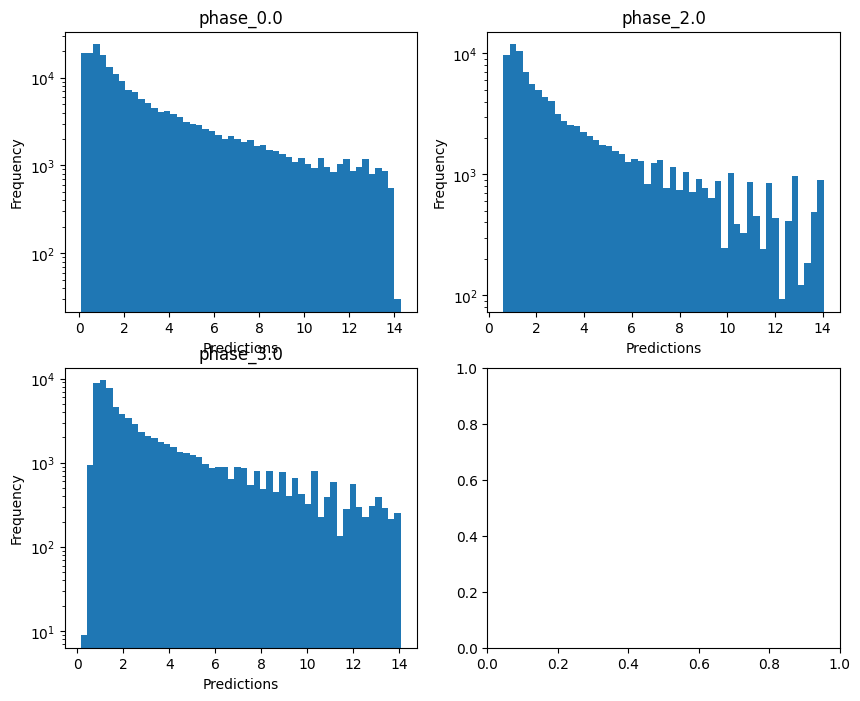

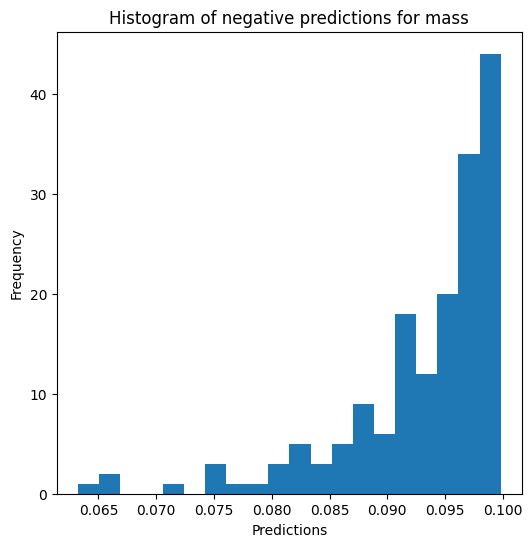


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9995096419055818
  RMSE :  0.009328748993874184
  MAE :  0.007098325080537378
  MedAE :  0.0055642414507039994
  CORR :  0.9997548140882503
  MAX_ER :  0.05595286087311027
  Percentiles : 
    75th percentile :  0.009936909222430824
    90th percentile :  0.01523523171528718
    95th percentile :  0.01909680333650553
    99th percentile :  0.027339827681015273

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.999423246163041
  RMSE :  0.011215222136222969
  MAE :  0.008705968069360802
  MedAE :  0.007059053881170896
  CORR :  0.9997118826192611
  MAX_ER :  0.07215287212604515
  Percentiles : 
    75th percentile :  0.012372419943804489
    90th percentile :  0.01830971967827428
    95th percentile :  0.02244686692459419
    99th percentile :  0.031231964736065754

radius results for th

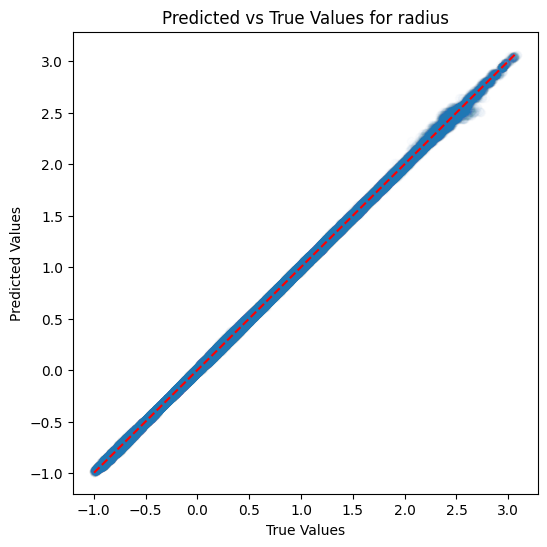

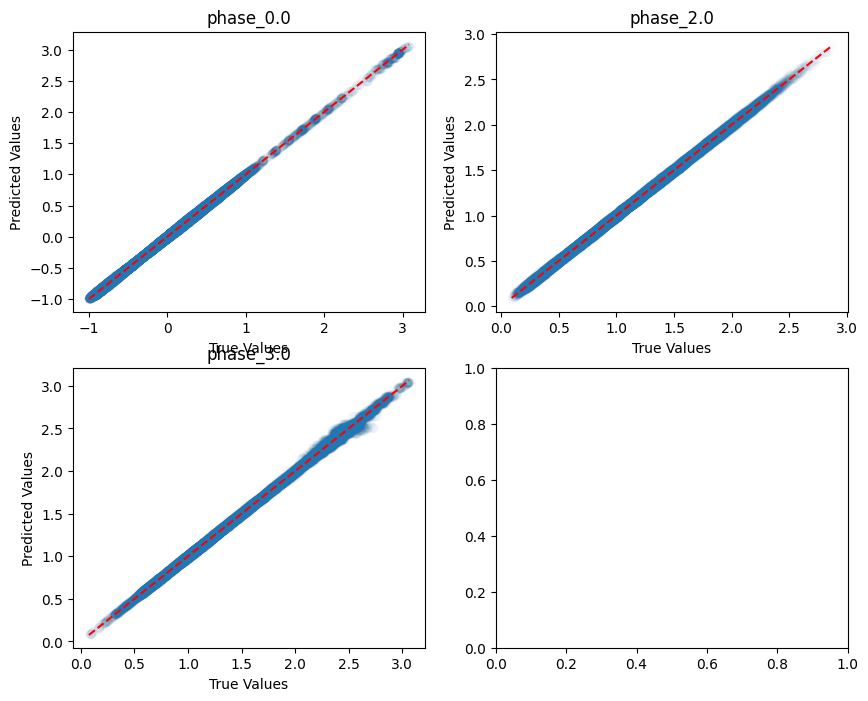

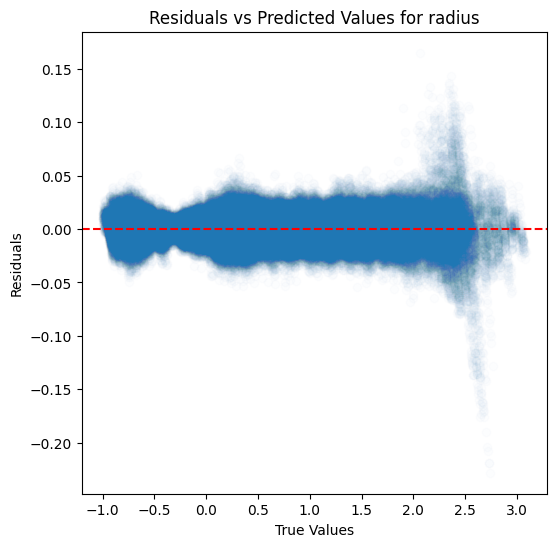

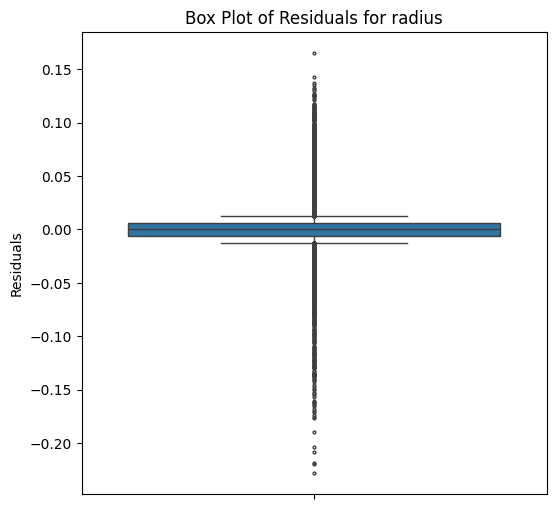

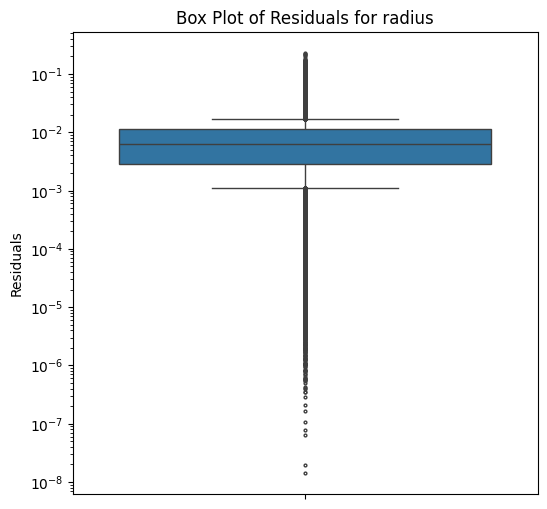

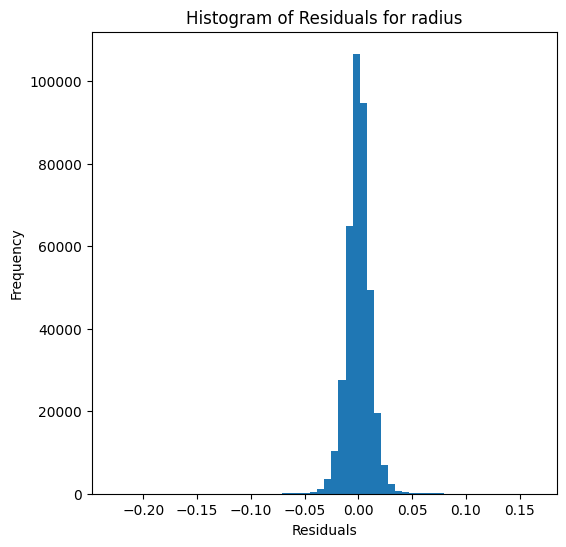

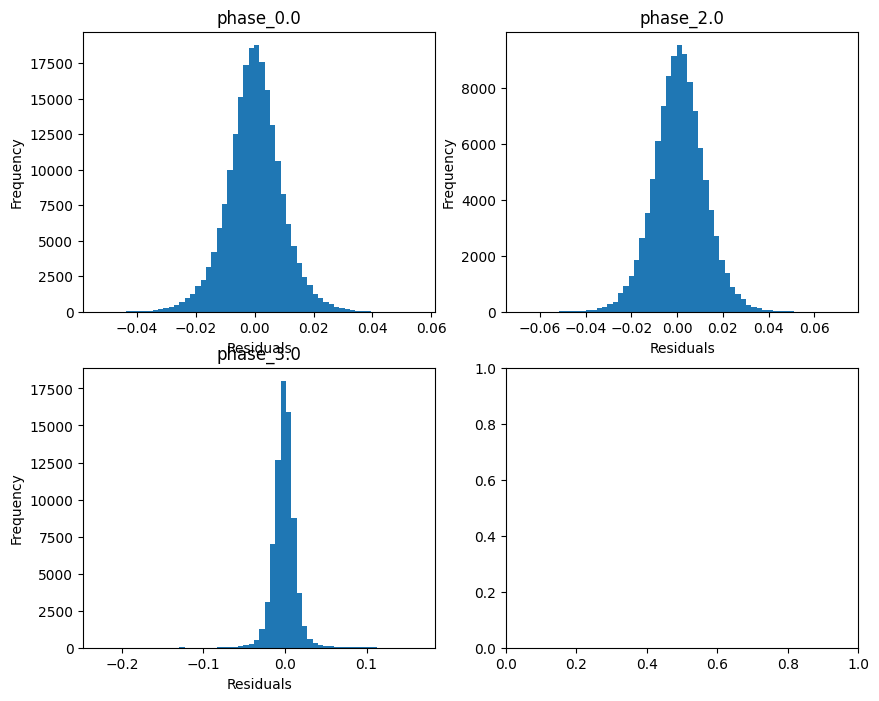

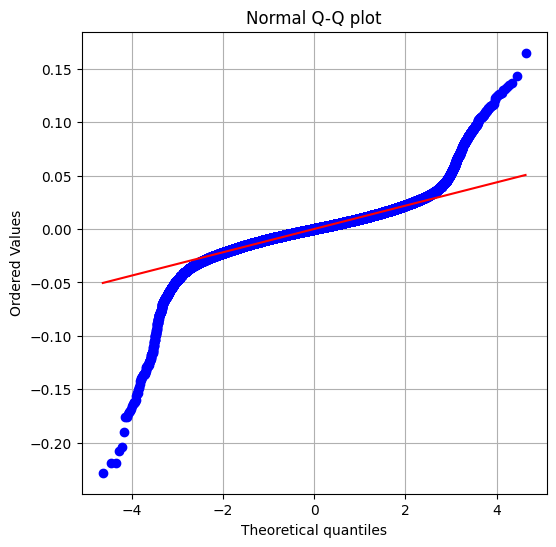

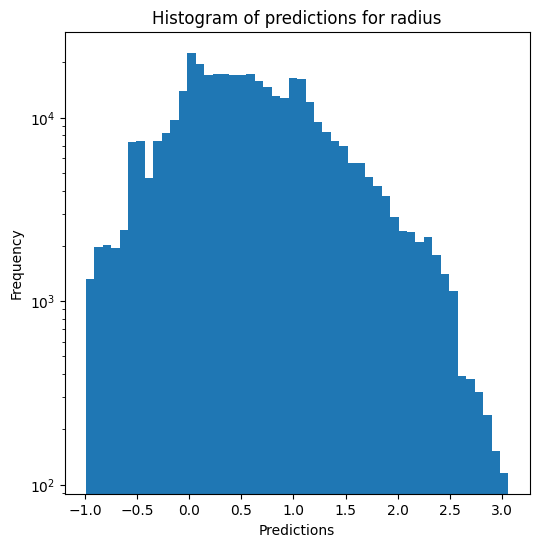

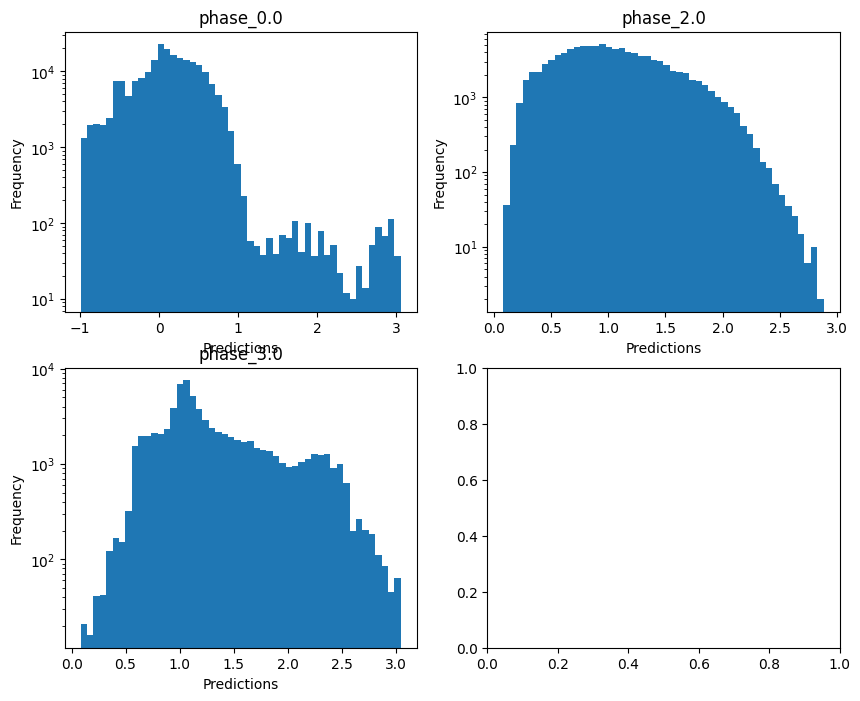

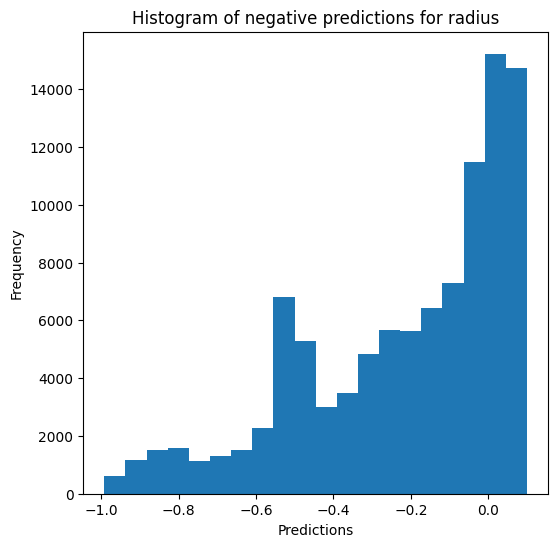

Saving predictions and results...


In [19]:
xgb_evaluator.evaluate_Kfold_results(XGBRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, random_state=12, override=override, use_preds=use_preds, save=save, show=show, scaler_name=scaler_name, n_jobs=5)

### Multi-layer perceptron

In [20]:
mlp_evaluator = Model_evaluator("mlp", path=path_to_results, physical_model=physical_model, output_parameters=output_parameters)


scale_robust_14 train data :
Performing K-fold...
Split 1 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0014629126381575555
2 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0014372755759432098
3 

...

0.0012644681290946882
4 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.001358929642727564
5 

c:\Users\antoi\Code\unif\MA2\thesis\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


0.0012390188780321105

Evaluating predictions...

mass results for the phase category with a value of 0.0
  value range :  0.0999979840073621 - 13.998624815474695
  RVE :  0.9997205938180765
  RMSE :  0.0551084115627926
  MAE :  0.026046489776603076
  MedAE :  0.014822814300096354
  CORR :  0.9998603017714275
  MAX_ER :  2.350817829652396
  Percentiles : 
    75th percentile :  0.0292399305731873
    90th percentile :  0.05509359342209681
    95th percentile :  0.08289293854648315
    99th percentile :  0.18258259014621597

mass results for the phase category with a value of 2.0
  value range :  0.6542770535966311 - 13.927740111688449
  RVE :  0.9997649156811659
  RMSE :  0.049759462036352245
  MAE :  0.03028075915593181
  MedAE :  0.019281235096057836
  CORR :  0.999882955804734
  MAX_ER :  0.9505139194870385
  Percentiles : 
    75th percentile :  0.03617531756543002
    90th percentile :  0.06624640825302872
    95th percentile :  0.0945628160943936
    99th percentile :  0.18937006

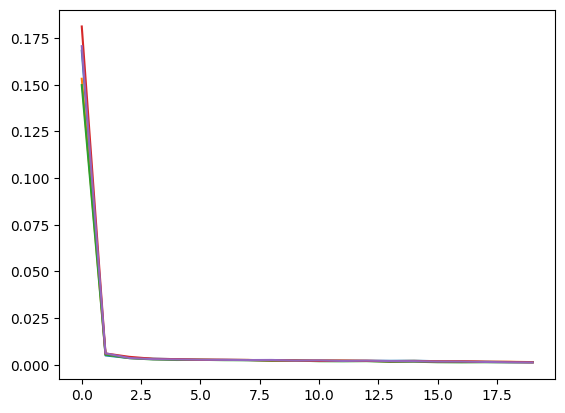

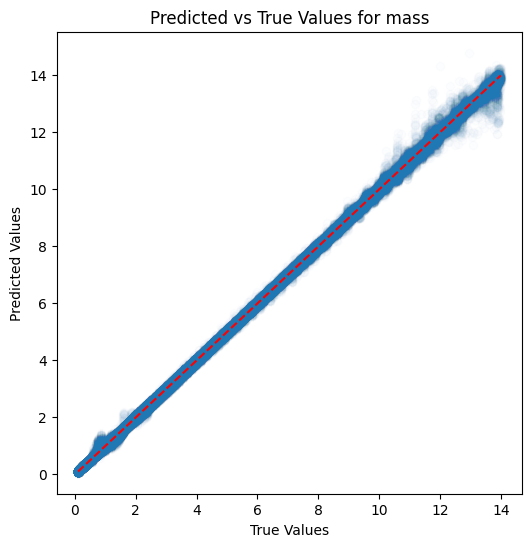

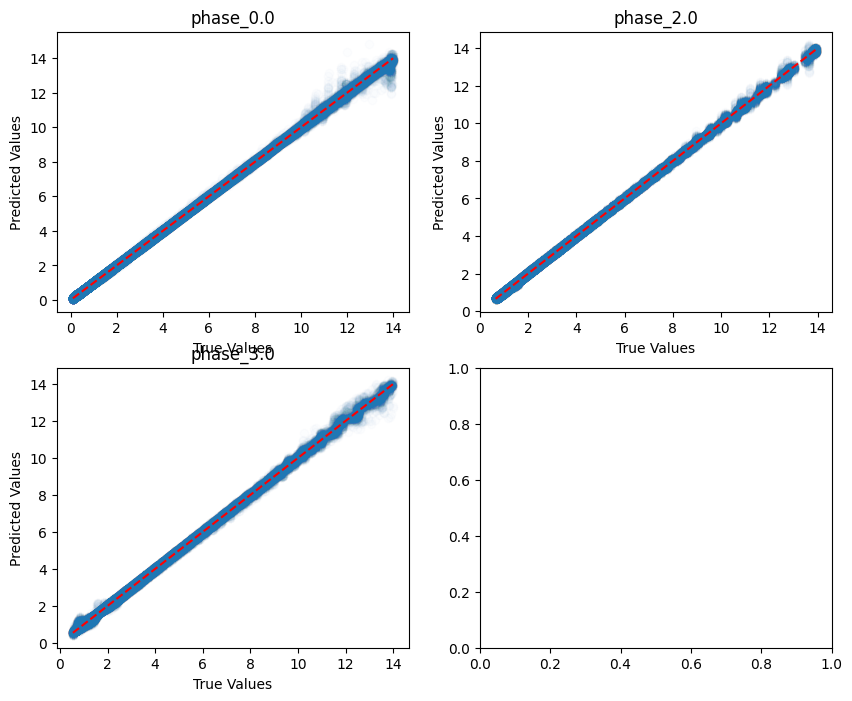

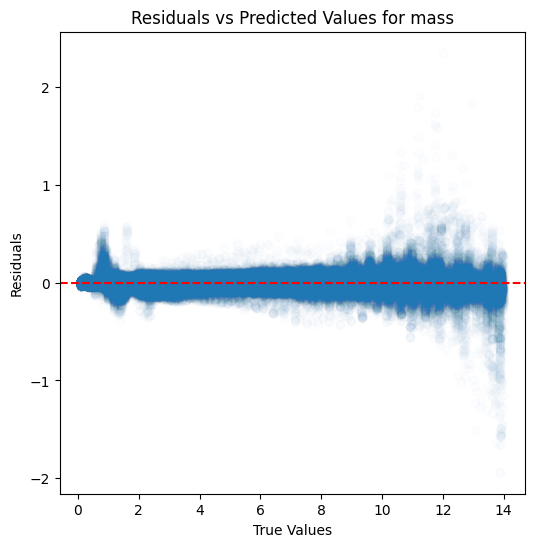

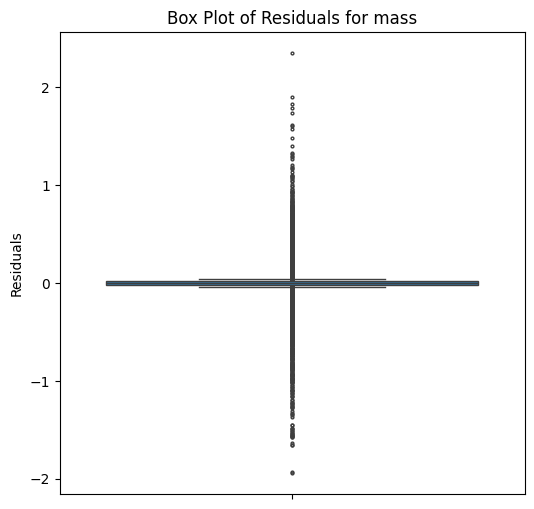

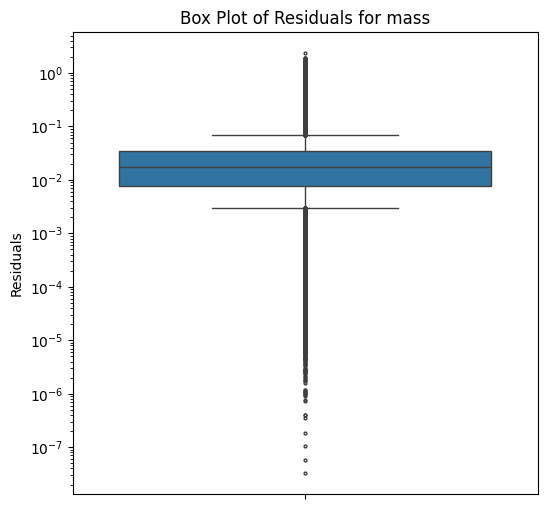

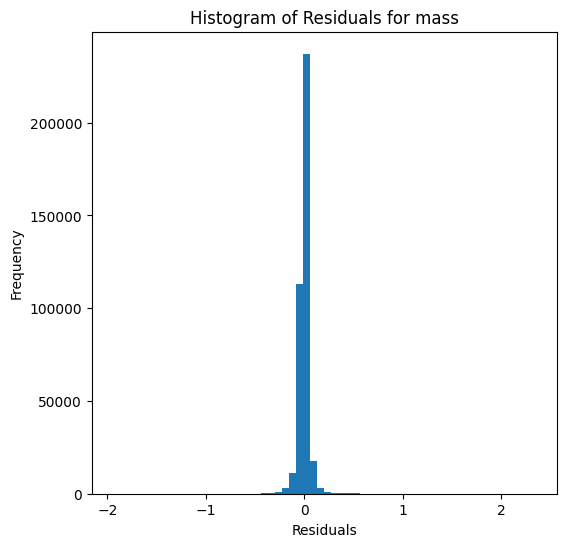

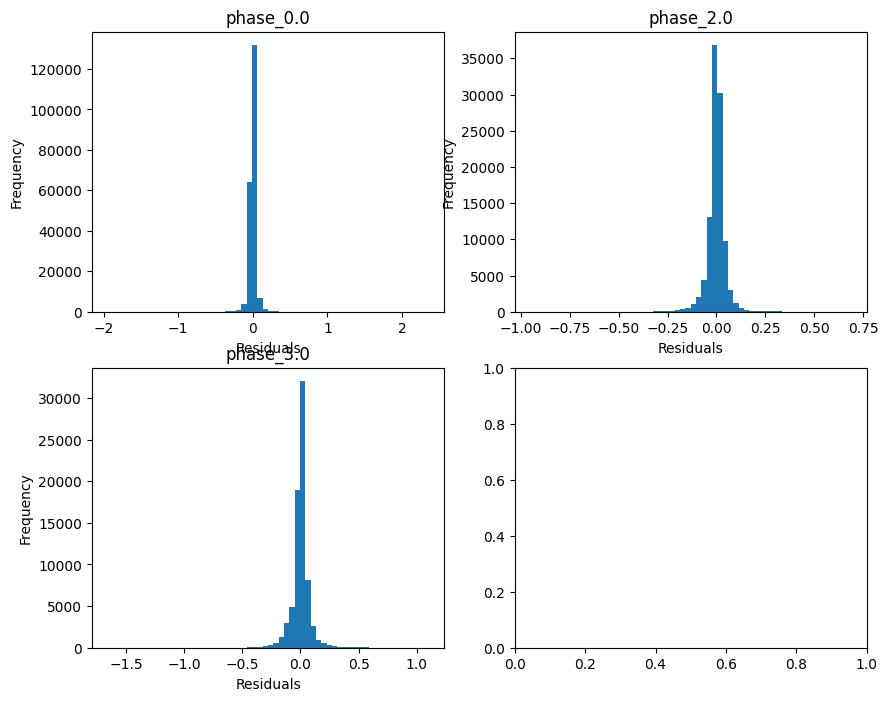

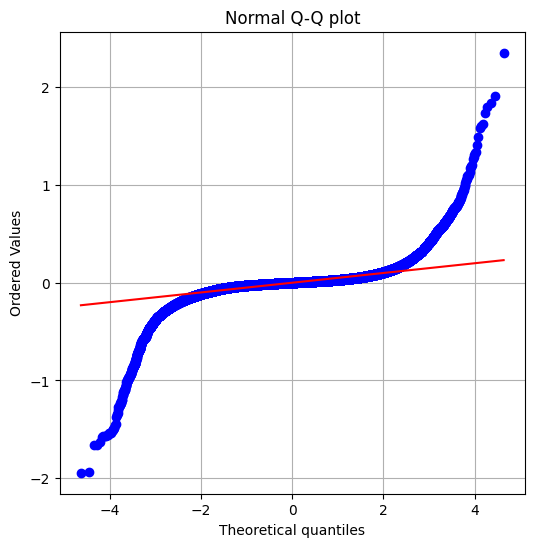

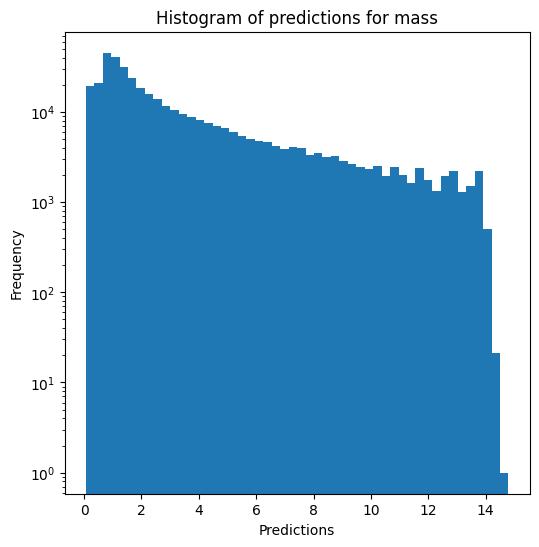

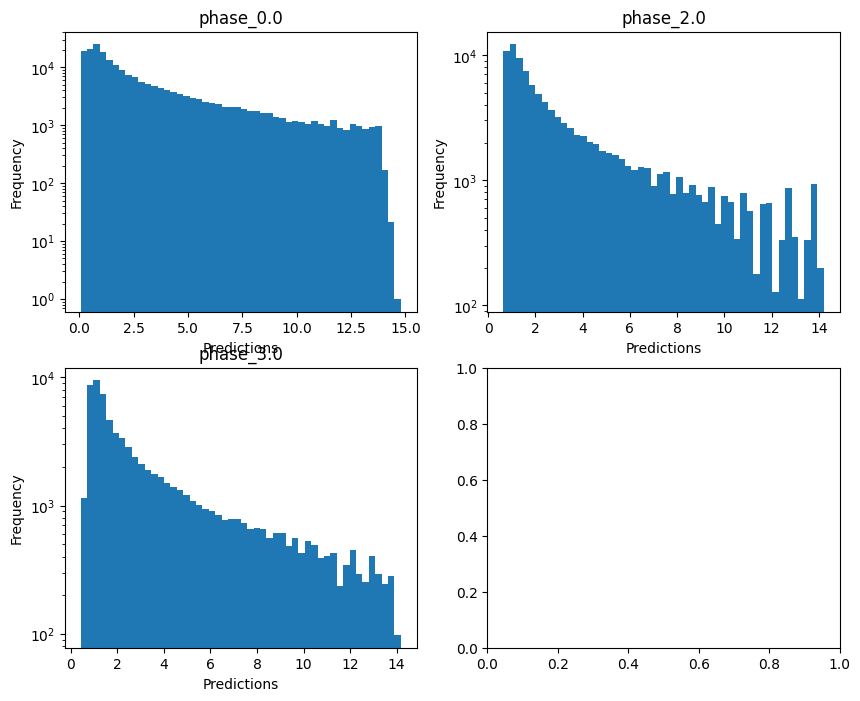

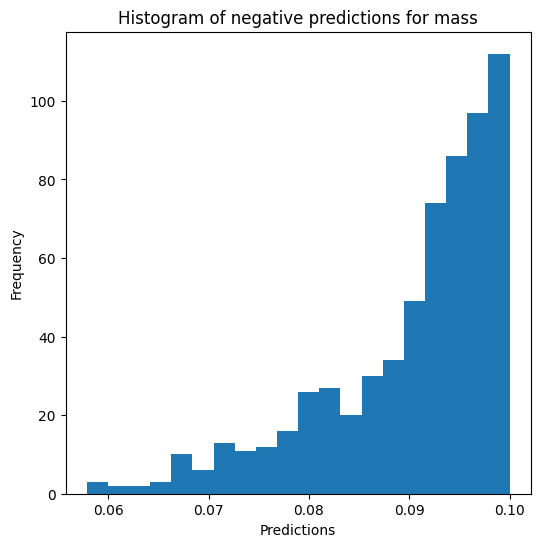


radius results for the phase category with a value of 0.0
  value range :  -0.9974747647513328 - 3.082068881511837
  RVE :  0.9994098445089257
  RMSE :  0.010770029427220931
  MAE :  0.008128249443080516
  MedAE :  0.006389706242053816
  CORR :  0.9997178121812917
  MAX_ER :  0.08482609445034628
  Percentiles : 
    75th percentile :  0.011268688445395969
    90th percentile :  0.017154729870130104
    95th percentile :  0.02185274749343964
    99th percentile :  0.032558268812136915

radius results for the phase category with a value of 2.0
  value range :  0.0909920840275404 - 2.8708569524681256
  RVE :  0.9991220679678366
  RMSE :  0.0138387606560287
  MAE :  0.010969245677251736
  MedAE :  0.00916460448662093
  CORR :  0.9995610737703049
  MAX_ER :  0.07614332915963251
  Percentiles : 
    75th percentile :  0.01550362292392446
    90th percentile :  0.022689934934412986
    95th percentile :  0.02753797621516891
    99th percentile :  0.03713385614223015

radius results for the p

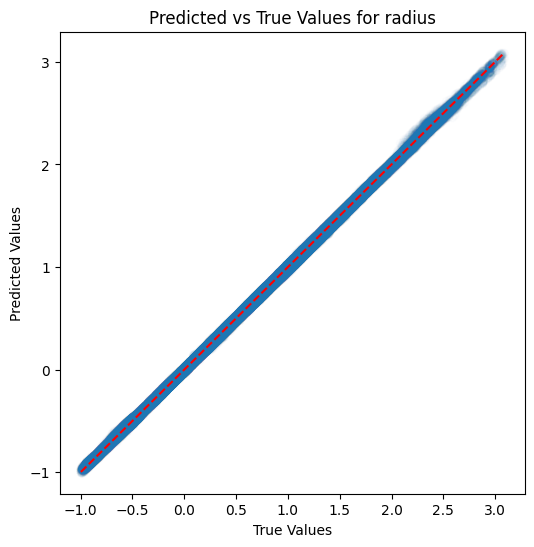

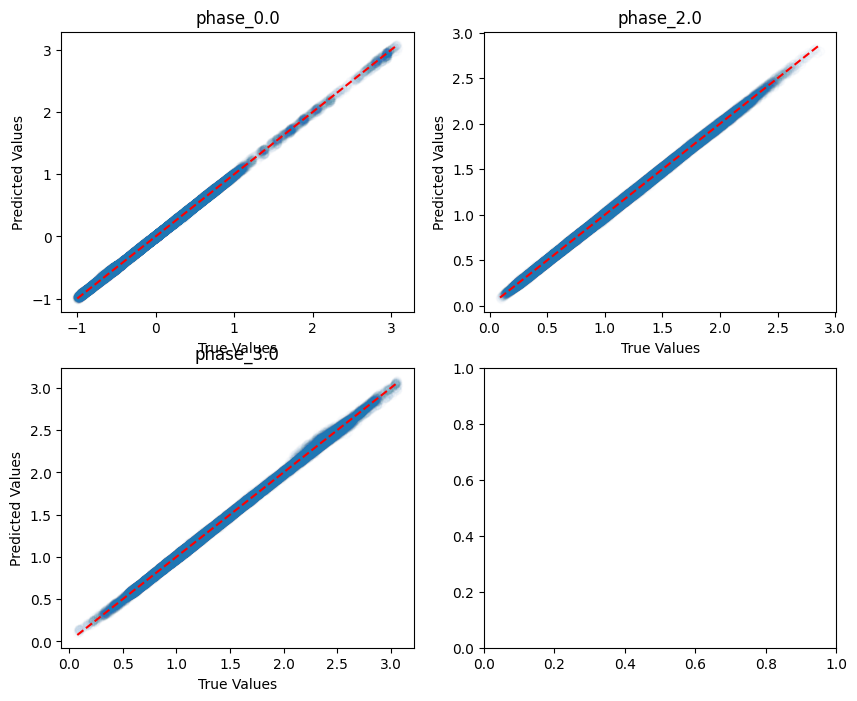

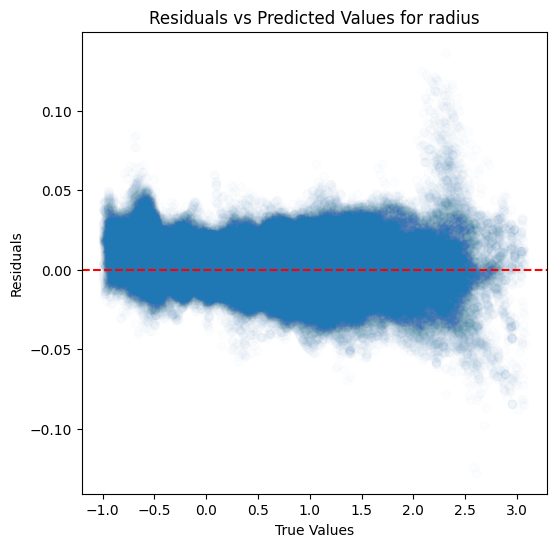

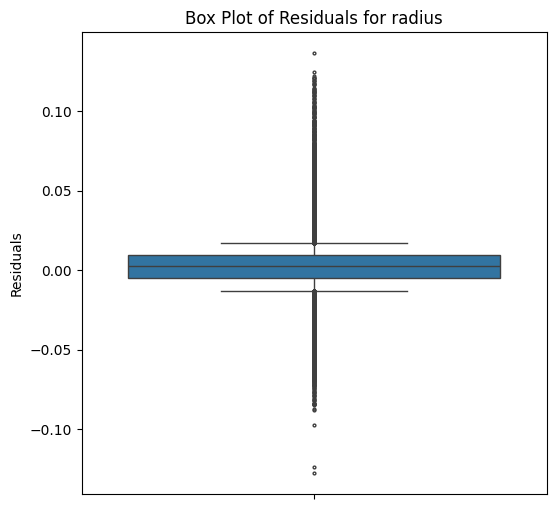

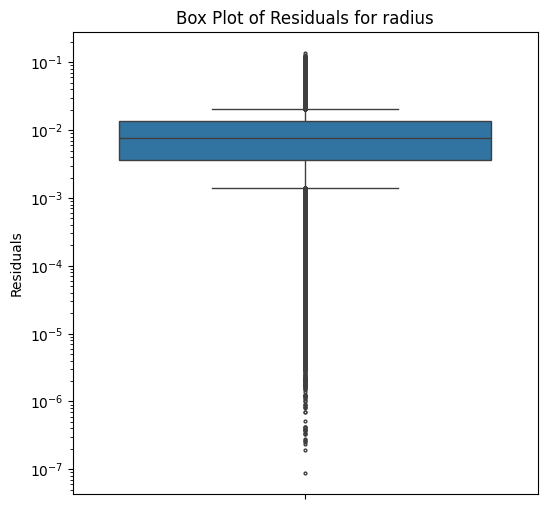

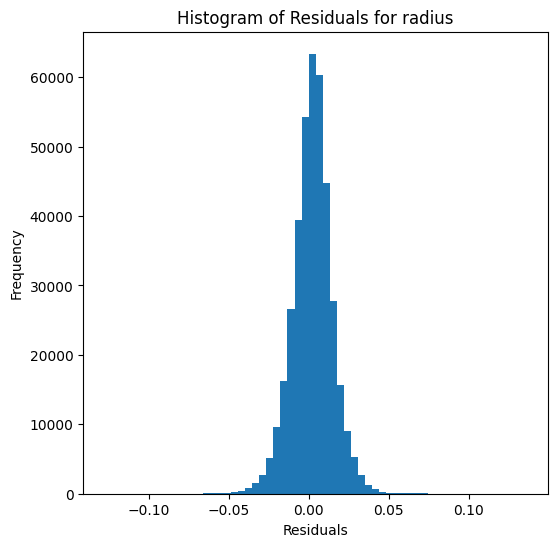

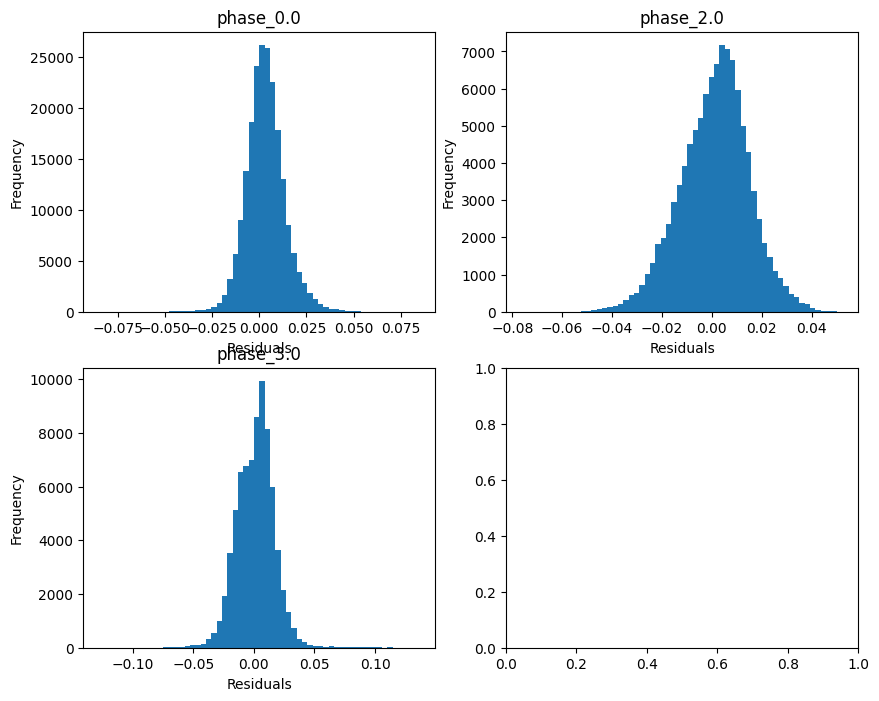

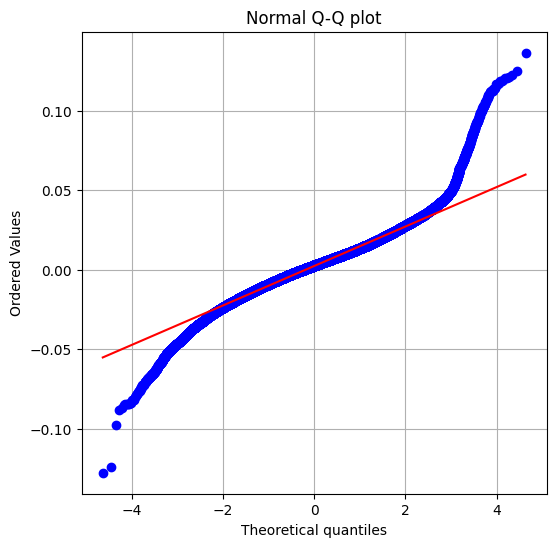

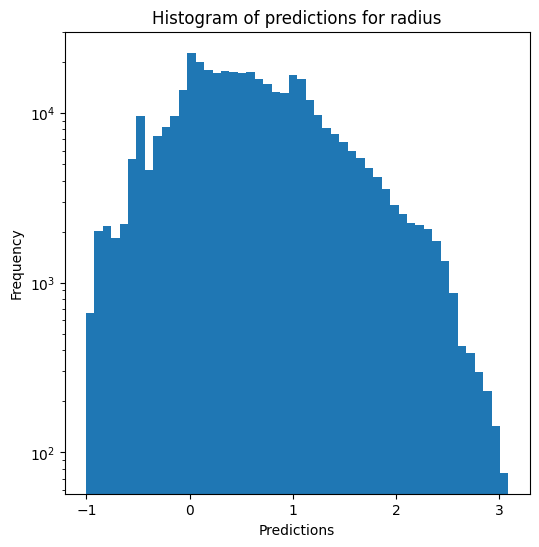

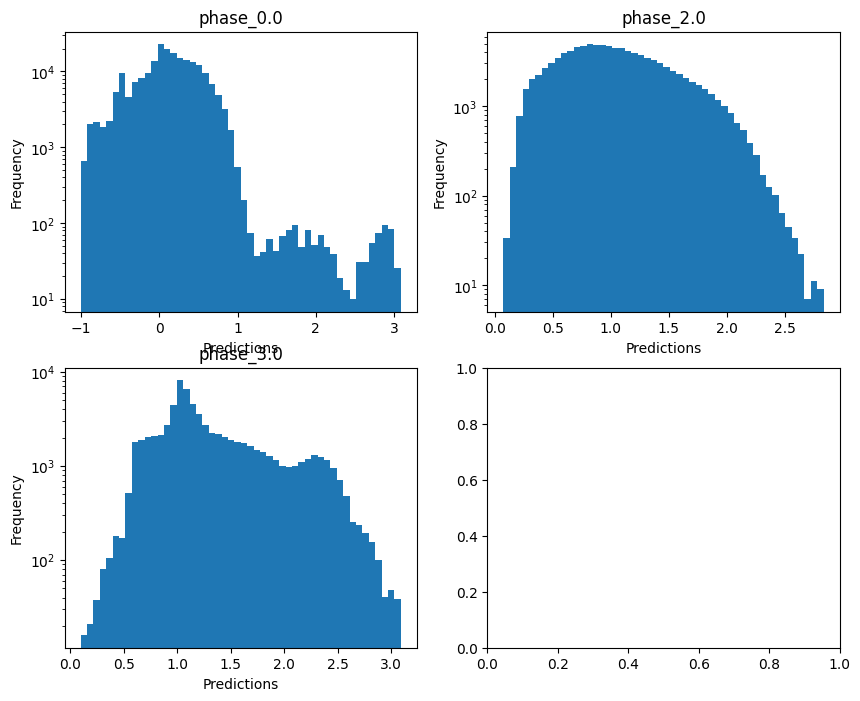

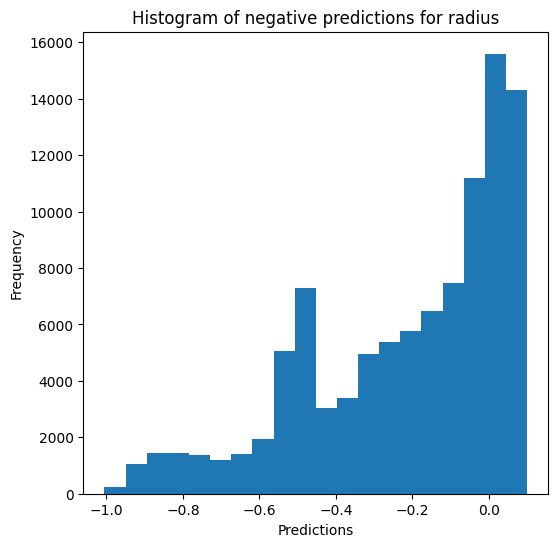

Saving predictions and results...


In [21]:
mlp_evaluator.evaluate_Kfold_results(MLPRegressor, X_train, y_train, categories_train, categories_name, path_to_predictions, tag, n_splits=5, random_state=12, override=override, use_preds=use_preds, save=save, scaler_name=scaler_name, show=show,
                                      hidden_layer_sizes = (100, 100, 100, 100), max_iter=20, batch_size=400)

Avec batch_size=auto (200):

plus de 30 minutes pour entrainer un seul split de Kfold avec les paramètres par défaut (1 hidden layer de taille 100)

plus de 15 minutes pour entrainer un seul split de Kfold avec les 1 hidden layer de taille 10

- et max_iter=20, hidden_layer_sizes=(100, 50, 25): ~5 minutes par fold (plutôt bon résultats)
- et max_iter=20, hidden_layer_sizes=(100, 100, 100): ~5 minutes par fold

Avec batch_size=400:


Avec learning_rate= :


hidden_layer_sizes = (100, 100), max_iter=20, batch_size=200 => 17 min pour 2 splits et min_loss de 2.1
RMSE = RVE :  0.984867927459382
RMSE :  2.5335132759292107
MAE :  0.7276983504493552
MedAE :  0.3034009994265745
CORR :  0.9927285673947535
MAX_ER :  169.74348568157313
Percentiles : 75th percentile :  0.5113604728134682 90th percentile :  1.1025928446049704 95th percentile :  2.1347654852226015 99th percentile :  9.897101952249908)

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=400 => 7 min pour 2 splits et min_loss de 2.2
RVE :  0.9797171492755655
RMSE :  2.983208723004754
MAE :  0.9125599339275378
MedAE :  0.43124518658659683
CORR :  0.9920536596906272
MAX_ER :  170.53076478793002
Percentiles : 75th percentile :  0.675744507049632 90th percentile :  1.2421052024331438 95th percentile :  2.441733387262636 99th percentile :  11.925724226452427

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=800 => 3 min pour 2 splits et min_loss de 2.3 et 2.7

hidden_layer_sizes = (100, 100), max_iter=20, batch_size=1600 => 3 min 30 pour 2 splits et min_loss de 7.8 et 3.8

=> batch_size plus grand == plus rapide mais moins bon